### Story line for the paper with the correct proportions of the current data: 
- Sequences tested in NGN2 neurons and undifferentiated WTC11 cells

In [1]:
import pandas as pd
import os
import yaml


config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

In [2]:
# read the file
# df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202506'], sep='\t')
# df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507'], sep='\t')
df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_combined'], sep='\t')
# df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_combined_neuro_ctrl'], sep='\t', low_memory=False)
# df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_with_annotation_groups_combined_neuro_ctrl'], sep='\t', low_memory=False)
# make the start and end to integers
df_elements_all_regions[col_start] = df_elements_all_regions[col_start].astype(int)
df_elements_all_regions[col_end] = df_elements_all_regions[col_end].astype(int)

df_elements_all_regions = df_elements_all_regions.loc[df_elements_all_regions['bcalm_data_exists_NGN2']].copy()
df_elements_all_regions

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,False,False,True,False,decreasing,no_effect,True,False,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,False,False,False,no_effect,no_effect,True,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,False,False,False,no_effect,no_effect,True,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,False,False,False,no_effect,no_effect,True,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,False,False,False,no_effect,no_effect,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,False,False,False,no_effect,no_effect,True,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,False,False,False,True,False,increasing,no_effect,True,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,False,False,False,no_effect,no_effect,True,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,False,False,False,no_effect,no_effect,True,False,False


In [3]:
df_elements_all_regions
df_elements_all_regions.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre'],
      dtype='object')

#### Overlap with ATAC NGN2 WTC11 cells (old, unpublished data)

In [4]:
df_elements_all_regions_bed = df_elements_all_regions[[col_chr, col_start, col_end, col_name, col_strand]]
df_elements_all_regions_bed['score'] = 0
df_elements_all_regions_bed[[col_chr, col_start, col_end, col_name, "score", col_strand]]
writing = False
if writing:
    df_elements_all_regions_bed.to_csv("/home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/80K_MPRA_all_sequence_regions.bed", sep='\t', header=False, index=False)

/tmp/ipykernel_24576/1731434680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elements_all_regions_bed['score'] = 0


In [5]:
# bedtools intersect -a /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/80K_MPRA_all_sequence_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak -f 0.333333 -wa > /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/overlap_1_3_tested_sequences.bed

In [6]:
# bedtools intersect -a /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/80K_MPRA_all_sequence_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak -f 1.0 -wa > /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/overlap_whole_tested_sequences.bed

In [7]:
overlap_1_3_df = pd.read_csv(
    '/home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/overlap_1_3_tested_sequences.bed',
    sep='\t',
    header=None,
    usecols=[3], # Get the 4th column (index 3), which is 'name'
    names=['name']
)

overlap_1_3_df
# Get unique names of sequences that overlap
overlapping_names_1_3 = overlap_1_3_df['name'].unique()

# Add the new column to your original DataFrame
df_elements_all_regions['is_open_NGN2_WTC11_ATAC_1_3_overlap'] = df_elements_all_regions['name'].isin(overlapping_names_1_3)


In [8]:
df_elements_all_regions["is_open_NGN2_WTC11_ATAC_1_3_overlap"].value_counts()

is_open_NGN2_WTC11_ATAC_1_3_overlap
False    67470
True       771
Name: count, dtype: int64

In [9]:
df_elements_no_alternative = df_elements_all_regions.loc[~df_elements_all_regions['name'].str.startswith("cardiac_neuro_cava_random:ALT_")].copy()
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,False,True,False,decreasing,no_effect,True,False,False,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,False,False,no_effect,no_effect,True,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,False,False,no_effect,no_effect,True,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,False,False,no_effect,no_effect,True,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,False,False,no_effect,no_effect,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,False,False,no_effect,no_effect,True,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,False,False,True,False,increasing,no_effect,True,False,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,False,False,no_effect,no_effect,True,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,False,False,no_effect,no_effect,True,False,False,False


In [10]:
# add boolean bcalm effect:
df_elements_no_alternative['is_increasing_dCRE_NGN2'] = df_elements_no_alternative['is_dCRE_NGN2'] & (df_elements_no_alternative['raw_activity_NGN2_log2FC_bcalm'] > 0)
df_elements_no_alternative['is_decreasing_dCRE_NGN2'] = df_elements_no_alternative['is_dCRE_NGN2'] & (df_elements_no_alternative['raw_activity_NGN2_log2FC_bcalm'] < 0)
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2,is_decreasing_dCRE_NGN2
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,True,False,decreasing,no_effect,True,False,False,False,False,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,no_effect,no_effect,True,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,no_effect,no_effect,True,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,no_effect,no_effect,True,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,no_effect,no_effect,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,True,False,increasing,no_effect,True,False,False,False,True,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,no_effect,no_effect,True,False,False,False,False,False


In [11]:
df_elements_all_regions.columns


Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap'],
      dtype='object')

In [12]:
df_elements_all_regions.groupby(["is_dCRE_NGN2", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')

,is_dCRE_NGN2,is_open_NGN2_WTC11_ATAC_1_3_overlap,count
0,False,False,63949
1,False,True,531
2,True,False,3521
3,True,True,240


In [13]:
df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')

,is_dCRE_NGN2,is_open_NGN2_WTC11_ATAC_1_3_overlap,count
0,False,False,24035
1,False,True,185
2,True,False,1273
3,True,True,85


           offen       nicht offen
activity   85    (a)        1273 (b)
no activity  222 (c)        25902 (d)

In [14]:
(85/(85 + 1273))/(222/(222 + 25902))

7.365561437726385

In [15]:
df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_NPC_SCREEN_cCRE"]).size().reset_index(name='count')

,is_dCRE_NGN2,is_NPC_SCREEN_cCRE,count
0,False,False,23146
1,False,True,1074
2,True,False,1238
3,True,True,120


In [16]:
df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_NPC_SCREEN_cCRE", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')

,is_dCRE_NGN2,is_NPC_SCREEN_cCRE,is_open_NGN2_WTC11_ATAC_1_3_overlap,count
0,False,False,False,23003
1,False,False,True,143
2,False,True,False,1032
3,False,True,True,42
4,True,False,False,1182
5,True,False,True,56
6,True,True,False,91
7,True,True,True,29


In [17]:
# df_elements_all_regions.groupby(["is_dCRE_NGN2", "is_NPC_SCREEN_cCRE"]).size().reset_index(name='count')


In [18]:
df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_NPC_SCREEN_cCRE"]).size().reset_index(name='count')

,is_dCRE_NGN2,is_NPC_SCREEN_cCRE,count
0,False,False,23146
1,False,True,1074
2,True,False,1238
3,True,True,120


In [19]:
df_elements_all_regions.groupby(["is_dCRE_undiffWTC11", "is_NPC_SCREEN_cCRE"]).size().reset_index(name='count')

,is_dCRE_undiffWTC11,is_NPC_SCREEN_cCRE,count
0,False,False,64611
1,False,True,3204
2,True,False,332
3,True,True,94


In [20]:
df_elements_all_regions.groupby(["is_dCRE_undiffWTC11", "is_WTC11_SCREEN_cCRE"]).size().reset_index(name='count')


,is_dCRE_undiffWTC11,is_WTC11_SCREEN_cCRE,count
0,False,False,67217
1,False,True,598
2,True,False,384
3,True,True,42


In [21]:
df_elements_all_regions.groupby(["is_dCRE_undiffWTC11", "is_H9_SCREEN_cCRE"]).size().reset_index(name='count')


,is_dCRE_undiffWTC11,is_H9_SCREEN_cCRE,count
0,False,False,65672
1,False,True,2143
2,True,False,320
3,True,True,106


In [22]:
df_elements_all_regions.groupby(["is_dCRE_undiffWTC11", "is_H1_SCREEN_cCRE"]).size().reset_index(name='count')

,is_dCRE_undiffWTC11,is_H1_SCREEN_cCRE,count
0,False,False,65425
1,False,True,2390
2,True,False,262
3,True,True,164


In [23]:
df_elements_all_regions.groupby(["is_dCRE_NGN2", "is_H9_SCREEN_cCRE"]).size().reset_index(name='count')
df_elements_all_regions.groupby(["is_dCRE_NGN2", "is_H1_SCREEN_cCRE"]).size().reset_index(name='count')


,is_dCRE_NGN2,is_H1_SCREEN_cCRE,count
0,False,False,62209
1,False,True,2271
2,True,False,3478
3,True,True,283


#### SCREEN v3 and SCREEN v4 overlap: How many ids from our tested SCREEN ID set are still in the SCREEN v4 set? (Because we would like to use SCREEN v4 for the comparison with marks)

In [24]:
screen_v4 = pd.read_csv(
    '/home/kisa/coding/80K_MPRA/cCREs_overlap/GRCh38-cCREs.bed',
    sep='\t',
    header=None,
)

screen_v4.columns = ['chr', 'start', 'end', 'name', 'SCREEN_ID', 'annotation']
screen_v4

,chr,start,end,name,SCREEN_ID,annotation
0,chr1,10033,10250,EH38D4327497,EH38E2776516,pELS
1,chr1,10385,10713,EH38D4327498,EH38E2776517,pELS
2,chr1,16097,16381,EH38D6144701,EH38E3951272,CA-CTCF
3,chr1,17343,17642,EH38D6144702,EH38E3951273,CA-TF
4,chr1,29320,29517,EH38D6144703,EH38E3951274,CA
...,...,...,...,...,...,...
2348849,chrY,26670948,26671287,EH38D6144696,EH38E3951269,dELS
2348850,chrY,26671292,26671478,EH38D6144697,EH38E3951270,dELS
2348851,chrY,26671538,26671787,EH38D6473458,EH38E4535242,dELS
2348852,chrY,56684007,56684171,EH38D6144699,EH38E4535243,CA


In [25]:
df_elements_screen_ids = set(df_elements_all_regions['SCREEN_ID'].to_list())
df_elements_screen_ids

screen_v4_screen_ids = set(screen_v4['SCREEN_ID'].to_list())
screen_v4_screen_ids
print("Number of all SCREEN IDs in 80k elements:", len(df_elements_screen_ids))
print("Number of SCREEN IDs in v4:", len(screen_v4_screen_ids))
print("Number of overlapping SCREEN IDs:", len(df_elements_screen_ids.intersection(screen_v4_screen_ids)))
print("Proportion of overlapping SCREEN IDs:", round(len(df_elements_screen_ids.intersection(screen_v4_screen_ids)) / len(df_elements_screen_ids)*100), "%")
print("Number of unique SCREEN IDs from version 3: ", len(df_elements_screen_ids - screen_v4_screen_ids))
screen_missing_in_v4 = df_elements_screen_ids - screen_v4_screen_ids

Number of all SCREEN IDs in 80k elements: 25995
Number of SCREEN IDs in v4: 2348854
Number of overlapping SCREEN IDs: 25190
Proportion of overlapping SCREEN IDs: 97 %
Number of unique SCREEN IDs from version 3:  805


In [26]:
df_elements_no_alternative = df_elements_all_regions.loc[~df_elements_all_regions['name'].str.startswith("cardiac_neuro_cava_random:ALT_")].copy()
df_elements_no_alternative

# add boolean bcalm effect:
df_elements_no_alternative['is_increasing_dCRE_NGN2'] = df_elements_no_alternative['is_dCRE_NGN2'] & (df_elements_no_alternative['raw_activity_NGN2_log2FC_bcalm'] > 0)
df_elements_no_alternative['is_decreasing_dCRE_NGN2'] = df_elements_no_alternative['is_dCRE_NGN2'] & (df_elements_no_alternative['raw_activity_NGN2_log2FC_bcalm'] < 0)
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2,is_decreasing_dCRE_NGN2
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,True,False,decreasing,no_effect,True,False,False,False,False,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,no_effect,no_effect,True,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,no_effect,no_effect,True,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,no_effect,no_effect,True,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,no_effect,no_effect,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,True,False,increasing,no_effect,True,False,False,False,True,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,no_effect,no_effect,True,False,False,False,False,False


##### How many variants and elements are affected: 

In [27]:
df_elements_all_regions_screen_v4 = df_elements_all_regions.loc[df_elements_all_regions['SCREEN_ID'].isin(screen_missing_in_v4)].copy()
df_elements_all_regions_screen_v4

# get number of variants (number of ALT_ containing names)
df_elements_all_regions_screen_v4_variants = df_elements_all_regions_screen_v4.loc[df_elements_all_regions_screen_v4['name'].str.contains("cardiac_neuro_cava_random:ALT_")].copy()
df_elements_all_regions_screen_v4_variants # 1432 variants

n_overall_designed_variants = df_elements_all_regions.loc[df_elements_all_regions['name'].str.contains("cardiac_neuro_cava_random:ALT_")].shape[0]
print("Proportion to overall number of variants: ", round(len(df_elements_all_regions_screen_v4_variants) / n_overall_designed_variants * 100, 2), "%") # 3.36%

Proportion to overall number of variants:  3.36 %


In [28]:
df_elements_all_regions_screen_v4

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap
43,cardiac_neuro_cava_random:ACTB|ENSG00000075624...,chr7,5596991,5597261,-,GAGTAGCTGGGACGACAGGCGTGCATCACCATGCCTGGCTAATTTT...,tested,-0.038200,1.000000,-0.596051,...,False,False,False,False,no_effect,no_effect,True,False,False,False
57,cardiac_neuro_cava_random:ACTL6B|ENSG000000770...,chr7,100677029,100677299,-,ACCCCCTTCCCTTTGGGTGGGAGAAGGTAGGGTCTCTCTCTGTTGT...,tested,-0.002413,1.000000,0.329393,...,False,False,False,False,no_effect,no_effect,True,False,False,False
193,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,chr1,27590937,27591207,-,CTGTTGGCAGACTCCTTAGGGCCATGCTCCCTCCCCATCAATCTGA...,tested,-0.014292,1.000000,0.022219,...,False,False,False,False,no_effect,no_effect,True,False,False,False
194,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,chr1,27593644,27593914,-,GAAGAAGCAACTGCAGTGCTGTGGGAAGGGTCCCCAAGACATCGCC...,tested,0.111545,0.000419,3.276397,...,False,False,True,False,increasing,no_effect,True,False,False,False
195,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,chr1,27595643,27595913,-,ACTTCCACACACACACTCTACATACAGATACCCCCCGACATCCAGC...,tested,0.043344,0.578448,1.512705,...,False,False,False,False,no_effect,no_effect,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73329,cardiac_neuro_cava_random:TRIP12|ENSG000001538...,chr2,229835677,229835947,-,GGGAGAGGAGTTTTTTCCCATATTTGTTTTCCTAGAATAGTTTTTT...,tested,0.004300,1.000000,0.502997,...,False,False,False,False,no_effect,no_effect,True,False,False,False
73350,cardiac_neuro_cava_random:TSC1|ENSG00000165699...,chr9,132889572,132889842,-,GCTCAGGAGCCACAAAATCAGAATTCTGGCTTCTGTCATGGTCTCC...,tested,-0.093473,0.066973,-2.025434,...,False,False,False,False,no_effect,no_effect,True,False,False,False
73517,cardiac_neuro_cava_random:VEGFA|ENSG0000011271...,chr6,43793612,43793882,+,GCCACAAGAGGATGTCTTCTGGGGAAATATTCAGGGAGGGTGTTTG...,tested,0.012658,1.000000,0.719146,...,False,False,False,False,no_effect,no_effect,True,False,False,False
73691,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,chr16,79091070,79091340,+,AGCCACCGCTCCAGGCCTAGAAAGACTGGATTTTACCCTGATTGAG...,tested,-0.014283,1.000000,0.022440,...,False,False,False,False,no_effect,no_effect,True,False,False,False


### Investigate the number and amounts of sequences without alternative which are overlapping a SCREE cCRE in neuron cells

In [29]:
# filter down to only look into the SCREEN v4 regions
df_elements_no_alternative = df_elements_no_alternative.loc[df_elements_no_alternative['SCREEN_ID'].isin(screen_v4_screen_ids)].copy()
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2,is_decreasing_dCRE_NGN2
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,True,False,decreasing,no_effect,True,False,False,False,False,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,no_effect,no_effect,True,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,no_effect,no_effect,True,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,no_effect,no_effect,True,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,no_effect,no_effect,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,True,False,increasing,no_effect,True,False,False,False,True,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,no_effect,no_effect,True,False,False,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,no_effect,no_effect,True,False,False,False,False,False


In [30]:
df_elements_no_alternative.columns


Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap', 'is_increasing_dCRE_NGN2',
       'is_decreasing_dCRE_NGN2'],
      dtype='object')

Mit allen regionen: Auch die, die nur in SCREEN 3 sind

In [60]:
df_elements_no_alternative = df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].copy()

In [61]:
df_elements_no_alternative_count = df_elements_no_alternative.groupby(["is_dCRE_NGN2", "bcalm_effect_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')
df_elements_no_alternative_count = df_elements_no_alternative.groupby(["is_dCRE_NGN2", "bcalm_effect_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_npc_or_excitatory_NSC_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap", "is_excitatory_neuron_SCREEN_cCRE", "is_NPC_SCREEN_cCRE", "is_neural_stem_SCREEN_cCRE"]).size().reset_index(name='count')
# df_elements_no_alternative_count_neuro = df_elements_no_alternative.groupby(["is_dCRE_NGN2", "bcalm_effect_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_npc_or_excitatory_NSC_SCREEN_cre", "is_excitatory_neuron_SCREEN_cCRE", "is_NPC_SCREEN_cCRE", "is_neural_stem_SCREEN_cCRE"]).size().reset_index(name='count')
df_elements_no_alternative_count

,is_dCRE_NGN2,bcalm_effect_NGN2,is_npc_or_excitatory_SCREEN_cre,is_npc_or_excitatory_NSC_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_excitatory_neuron_SCREEN_cCRE,is_NPC_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,count
0,False,no_effect,False,False,False,False,False,False,21658
1,False,no_effect,False,False,True,False,False,False,99
2,False,no_effect,False,True,False,False,False,True,442
3,False,no_effect,False,True,True,False,False,True,11
4,False,no_effect,True,True,False,False,True,False,317
5,False,no_effect,True,True,False,False,True,True,627
6,False,no_effect,True,True,False,True,False,False,157
7,False,no_effect,True,True,False,True,False,True,21
8,False,no_effect,True,True,False,True,True,False,9
9,False,no_effect,True,True,False,True,True,True,79


In [62]:
df_elements_no_alternative_only_dCREs = df_elements_no_alternative.loc[df_elements_no_alternative['is_dCRE_NGN2']].copy()
df_elements_no_alternative_only_dCREs_count = df_elements_no_alternative_only_dCREs.groupby(["is_npc_or_excitatory_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')
df_elements_no_alternative_only_dCREs_count = df_elements_no_alternative_only_dCREs.groupby(["is_npc_or_excitatory_NSC_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')
df_elements_no_alternative_only_dCREs_count

,is_npc_or_excitatory_NSC_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,count
0,False,False,1089
1,False,True,41
2,True,False,139
3,True,True,42


#### Compute the enrichment of sequences with SCREEN marks in neural enhancers

In [63]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [64]:
print("\n--- Question 1: NGN2 Activity in is_npc_or_excitatory_NSC_SCREEN_cre vs. Others ---")
df_elements_ngn2_focus = df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].copy()
group_a_q1 = df_elements_ngn2_focus[df_elements_ngn2_focus['is_npc_or_excitatory_NSC_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']
group_b_q1 = df_elements_ngn2_focus[~df_elements_ngn2_focus['is_npc_or_excitatory_NSC_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_npc_or_excitatory_NSC_SCREEN_cre' size: {len(group_a_q1)}")
print(f"Group 'Others' size: {len(group_b_q1)}")

if len(group_a_q1) > 1 and len(group_b_q1) > 1: # Mann-Whitney requires at least 2 samples per group
    u_stat_q1, p_val_q1 = stats.mannwhitneyu(group_a_q1, group_b_q1, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q1:.2f}")
    print(f"P-value: {p_val_q1:.3e}") # Using scientific notation for small p-values

    if p_val_q1 < 0.05: # Common significance threshold
        print(f"Conclusion: Activity in 'is_npc_or_excitatory_NSC_SCREEN_cre' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_npc_or_excitatory_NSC_SCREEN_cre': {group_a_q1.median().round(3)}")
    print(f"Median activity for 'Others': {group_b_q1.median().round(3)}")
else:
    print("Not enough data in one or both groups for statistical testing.")



--- Question 1: NGN2 Activity in is_npc_or_excitatory_NSC_SCREEN_cre vs. Others ---
Group 'is_npc_or_excitatory_NSC_SCREEN_cre' size: 1902
Group 'Others' size: 22887
Mann-Whitney U Statistic: 23500071.00
P-value: 3.645e-09
Conclusion: Activity in 'is_npc_or_excitatory_NSC_SCREEN_cre' group is significantly higher (p < 0.05).
Median activity for 'is_npc_or_excitatory_NSC_SCREEN_cre': -0.007
Median activity for 'Others': -0.01


In [65]:
df_elements_no_alternative.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap', 'is_increasing_dCRE_NGN2',
       'is_decreasing_dCRE_NGN2'],
      dtype='object')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Other Elements vs. NPC+NSC+GN SCREEN cCRE: Mann-Whitney-Wilcoxon test two-sided, P_val:7.290e-09 U_stat=2.003e+07


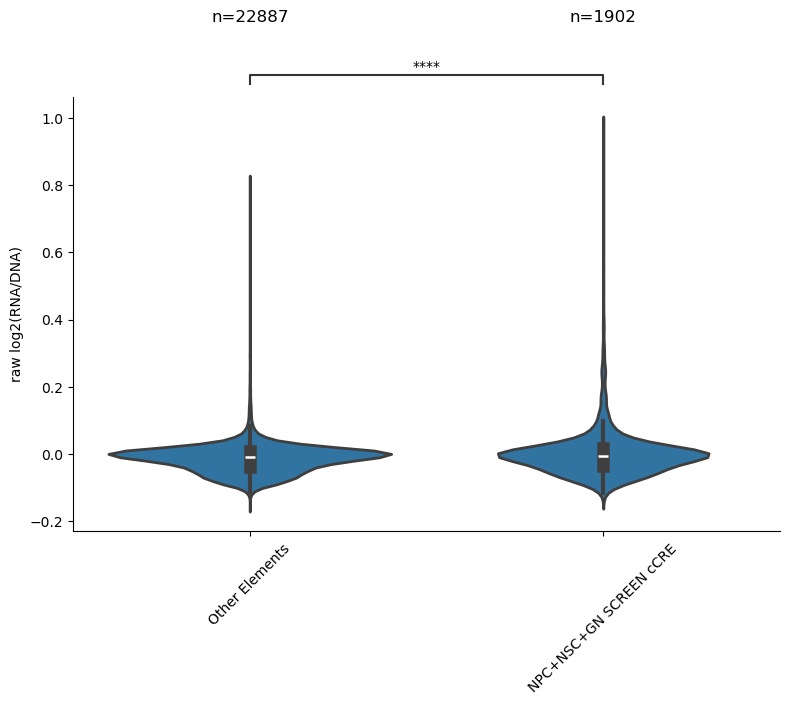

In [66]:
# Plot the acitivty distribution between
# plot a violin plot for each label
from statannotations.Annotator import Annotator
import seaborn as sns
y_axis_col = "not_shifted_bcalm_element_log_ratio_activity"
y_axis_col = "raw_activity_NGN2_log2FC_bcalm"
x_axis_col = "NPC_NSC_GN_SCREEN_Group"
fig, ax = plt.subplots(figsize=(8,6))

plot_activity_SCREEN = df_elements_no_alternative.copy()
plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'] = plot_activity_SCREEN['is_npc_or_excitatory_NSC_SCREEN_cre'].map({True: 'NPC+NSC+GN SCREEN cCRE', False: 'Other Elements'})

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=plot_activity_SCREEN, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('NPC+NSC+GN SCREEN cCRE', 'Other Elements')], data=plot_activity_SCREEN, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# annotate with the number of sequences in each group
ax.text(1, 1.3, f"n={plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'].value_counts()['NPC+NSC+GN SCREEN cCRE']}", ha='center', va='center', fontsize=12)
ax.text(0, 1.3, f"n={plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'].value_counts()['Other Elements']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Other Elements vs. NPC+NSC+GN SCREEN cCRE: Mann-Whitney-Wilcoxon test two-sided, P_val:7.290e-09 U_stat=2.003e+07


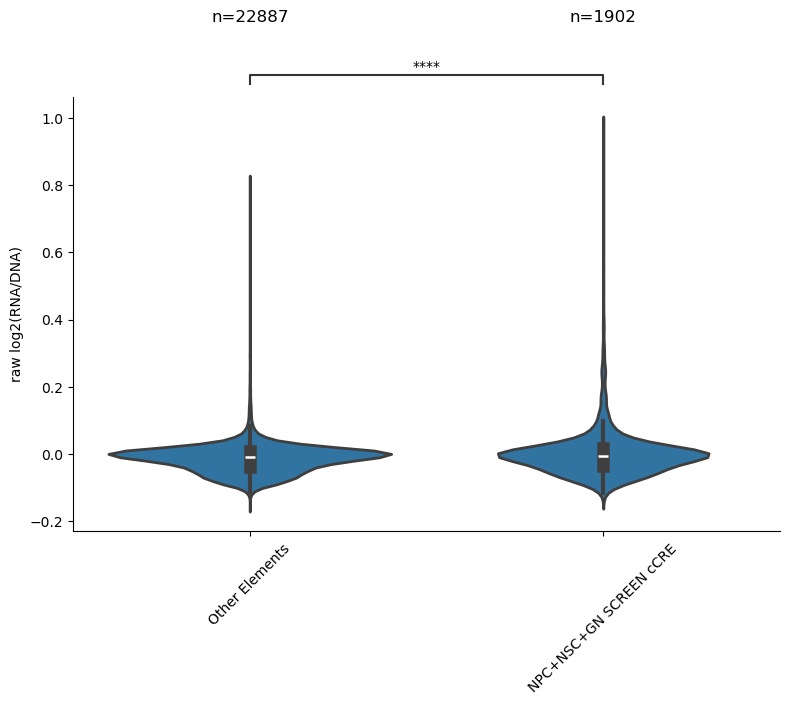

In [67]:
# Plot the acitivty distribution between
# plot a violin plot for each label
from statannotations.Annotator import Annotator
import seaborn as sns
y_axis_col = "not_shifted_bcalm_element_log_ratio_activity"
y_axis_col = "raw_activity_NGN2_log2FC_bcalm"
x_axis_col = "NPC_NSC_GN_SCREEN_Group"
fig, ax = plt.subplots(figsize=(8,6))

plot_activity_SCREEN = df_elements_no_alternative.copy()
plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'] = plot_activity_SCREEN['is_npc_or_excitatory_NSC_SCREEN_cre'].map({True: 'NPC+NSC+GN SCREEN cCRE', False: 'Other Elements'})

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=plot_activity_SCREEN, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('NPC+NSC+GN SCREEN cCRE', 'Other Elements')], data=plot_activity_SCREEN, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# annotate with the number of sequences in each group
ax.text(1, 1.3, f"n={plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'].value_counts()['NPC+NSC+GN SCREEN cCRE']}", ha='center', va='center', fontsize=12)
ax.text(0, 1.3, f"n={plot_activity_SCREEN['NPC_NSC_GN_SCREEN_Group'].value_counts()['Other Elements']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

#### Trying out Plotly sankey plot for the overlap of the sequences with epigenetic marks

In [68]:
# import pandas as pd
# import plotly.graph_objects as go

# # --- 2. Define Node Labels and Colors ---
# # A list of all unique node labels that will appear in the diagram.
# # The order here defines their index for source/target
# node_labels = [
#     "All Sequences",
#     "Significant regulatory sequences", "no significant regulatory activity", # Stage 1
#     "Considered cCRE in Neurons", "Not Considered cCRE in Neurons",                    # Stage 2 (from Sig: True)
#     "Open Chromatin: True", "Open Chromatin: False"     # Stage 3 (from Sig: True & Not Considered cCRE in Neurons)
# ]

# # Assigning unique indices to each node label
# label_to_index = {label: i for i, label in enumerate(node_labels)}

# # You can define colors for your nodes and links for better visualization
# node_colors = [
#     'lightgray',  # All Sequences
#     '#AEC6CF', '#FFADAD', # dCRE NGN2 (True/False) - Blue for True, Red for False
#     '#87CEEB', '#ADD8E6', # SCREEN (True/False) - Lighter blues
#     '#90EE90', '#FFDAB9'  # Open Chromatin (True/False) - Green for True, Peach for False
# ]

# link_colors = [] # Will be populated based on source/target node colors

# # --- 3. Prepare Source, Target, and Value Lists for Sankey ---
# sources = []
# targets = []
# values = []

# # --- Step 1: All Sequences -> is_dCRE_NGN2 (True/False) ---
# total_sequences = df_elements_no_alternative_count['count'].sum()
# sources.append(label_to_index["All Sequences"])
# targets.append(label_to_index["Significant regulatory sequences"])
# values.append(df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True]['count'].sum())
# link_colors.append(node_colors[label_to_index["Significant regulatory sequences"]])

# sources.append(label_to_index["All Sequences"])
# targets.append(label_to_index["no significant regulatory activity"])
# values.append(df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == False]['count'].sum())
# link_colors.append(node_colors[label_to_index["no significant regulatory activity"]])

# # --- Step 2: Significant regulatory sequences -> is_npc_or_excitatory_SCREEN_cre (True/False) ---
# # Filter for is_dCRE_NGN2 == True
# df_sig_true = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True]

# # Sig True -> SCREEN True
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["Considered cCRE in Neurons"])
# values.append(df_sig_true[df_sig_true["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum())
# link_colors.append(node_colors[label_to_index["Considered cCRE in Neurons"]])

# # Sig True -> SCREEN False
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["Not Considered cCRE in Neurons"])
# values.append(df_sig_true[df_sig_true["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum())
# link_colors.append(node_colors[label_to_index["Not Considered cCRE in Neurons"]])


# # --- Step 3: Branching for (Sig: True AND Not Considered cCRE in Neurons) -> Open Chromatin ---
# # This is the tricky part. We only branch for 'Open Chromatin' if SCREEN is False.
# df_sig_true_screen_false = df_sig_true[df_sig_true["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_sig_true_screen_false.empty:
#     # Sig True & SCREEN False -> Open Chromatin True
#     sources.append(label_to_index["Not Considered cCRE in Neurons"])
#     targets.append(label_to_index["Open Chromatin: True"])
#     values.append(df_sig_true_screen_false[df_sig_true_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: True"]])

#     # Sig True & SCREEN False -> Open Chromatin False
#     sources.append(label_to_index["Not Considered cCRE in Neurons"])
#     targets.append(label_to_index["Open Chromatin: False"])
#     values.append(df_sig_true_screen_false[df_sig_true_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: False"]])
# else:
#     print("No sequences found for 'is_dCRE_NGN2: True' AND 'is_npc_or_excitatory_SCREEN_cre: False'. The Open Chromatin branch won't appear.")


# # --- Important Note for Sankey Visuals ---
# # If a path leads to a leaf node (a node that doesn't flow further),
# # it's implicitly terminated. For example, 'no significant regulatory activity' and 'Considered cCRE in Neurons'
# # are end nodes in your specified flow.

# # --- 4. Create the Sankey Plot ---
# fig = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels,
#         color=node_colors
#     ),
#     link=dict(
#         source=sources,
#         target=targets,
#         value=values,
#         color=link_colors # Using link_colors to match target node color often looks good
#     )
# )])

# fig.update_layout(
#     title_text="Flow of Sequences through Annotation Criteria",
#     font_size=12,
#     height=600, # Adjust height as needed
#     width=900,  # Adjust width as needed
# )

# fig.show()

In [69]:
# import pandas as pd
# import plotly.graph_objects as go
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# # --- Initial Filtering: Start with only dCRE_NGN2 == True sequences ---
# df_initial_set = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True].copy()

# # --- 2. Define Node Labels and Colors ---
# # A list of all unique node labels that will appear in the diagram.
# # The order here defines their index for source/target
# node_labels = [
#     "Significant regulatory sequences",              # 0 (Now represents initial dCRE_NGN2=True set)
#     "Considered cCRE",                   # 1 (from All Sequences)
#     "Not Considered cCRE",               # 2 (from All Sequences)
#     "Within open-chromatin",                         # 3 (from Not Considered cCRE)
#     "Within closed chromatin"                         # 4 (from Not Considered cCRE)
# ]

# # Assigning unique indices to each node label for easy lookup.
# label_to_index = {label: i for i, label in enumerate(node_labels)}

# # Get the 'Pastel1' colormap from Matplotlib
# cmap = cm.get_cmap('Pastel1')

# # Define a subset of Pastel1 colors by explicitly picking indices for better visual distinction
# # and convert them to 'rgb(R,G,B)' strings for Plotly compatibility.
# # Pastel1 has 9 colors (indices 0-8).
# # Here we select specific colors from the palette for each node:
# node_colors_mapping = {
#     "Significant regulatory sequences": cmap(7),  # A muted gray-ish tone from Pastel1
#     "Considered cCRE": cmap(2),                  # A blue-ish tone from Pastel1
#     "Not Considered cCRE": cmap(0),              # an orange-ish tone from Pastel1
#     "Within open-chromatin": cmap(1),            # A green-ish tone from Pastel1
#     "Within closed chromatin": cmap(3)           # A red-ish tone from Pastel1
# }

# # Create the node_colors list in the correct order based on node_labels
# node_colors = [
#     f'rgb({int(node_colors_mapping[label][0]*255)},{int(node_colors_mapping[label][1]*255)},{int(node_colors_mapping[label][2]*255)})'
#     for label in node_labels
# ]

# # --- 3. Prepare Source, Target, and Value Lists for Sankey ---
# sources = []
# targets = []
# values = []
# link_colors = [] # Will be populated based on target node colors for visual consistency.

# # --- Step 1: Significant regulatory sequences -> Considered/Not Considered cCRE ---
# # The total count for the first node is the sum of counts in df_initial_set.
# total_dcre_sequences = df_initial_set['count'].sum()

# # Flow from "Significant regulatory sequences" to "Considered cCRE"
# considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum()
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["Considered cCRE"])
# values.append(considered_count)
# link_colors.append(node_colors[label_to_index["Considered cCRE"]])

# # Flow from "Significant regulatory sequences" to "Not Considered cCRE"
# not_considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum()
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["Not Considered cCRE"])
# values.append(not_considered_count)
# link_colors.append(node_colors[label_to_index["Not Considered cCRE"]])

# # --- Step 2: Branching for (Not Considered cCRE) -> Open Chromatin ---
# # This branch only applies to sequences that were "Not Considered cCRE".
# df_not_considered = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_not_considered.empty:
#     # Flow from "Not Considered cCRE" to "Within open-chromatin"
#     sources.append(label_to_index["Not Considered cCRE"])
#     targets.append(label_to_index["Within open-chromatin"])
#     values.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Within open-chromatin"]])

#     # Flow from "Not Considered cCRE" to "Within closed chromatin"
#     sources.append(label_to_index["Not Considered cCRE"])
#     targets.append(label_to_index["Within closed chromatin"])
#     values.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Within closed chromatin"]])
# else:
#     # This message will only print if the df_not_considered DataFrame is empty,
#     # meaning there are no sequences in the "Not Considered cCRE" branch to further split.
#     print("No sequences found for 'Not Considered cCRE'. The Open Chromatin branches won't appear.")


# # --- 4. Create the Sankey Plot ---
# fig = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15, # Padding between nodes
#         thickness=20, # Thickness of the nodes
#         line=dict(color="black", width=0.5), # Border for nodes
#         label=node_labels, # Labels for each node
#         color=node_colors # Colors for each node
#     ),
#     link=dict(
#         source=sources, # List of source node indices
#         target=targets, # List of target node indices
#         value=values,   # List of flow values
#         color=link_colors # Colors for each link, matching target node color
#     )
# )])

# fig.update_layout(
#     title_text="Flow of Significant Regulatory Sequences through Annotation Criteria",
#     font_size=12,
#     height=600, # Adjust height as needed for clarity
#     width=900,  # Adjust width as needed for clarity
# )

# fig.show()

In [70]:
# import pandas as pd
# import plotly.graph_objects as go
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# # --- Dummy DataFrame for demonstration ---
# # YOU MUST REPLACE THIS WITH YOUR ACTUAL df_elements_no_alternative_count DATAFRAME
# # This dummy data ensures the script is runnable for testing purposes.
# # It simulates the output of a groupby operation with boolean columns and a 'count'.
# df_initial_set = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True].copy()


# # --- 2. Define Node Labels and Colors ---
# # A list of all unique node labels that will appear in the diagram.
# # The order here defines their index for source/target.
# node_labels = [
#     "Significant regulatory sequences",  # 0 (This is now the starting point of the flow)
#     "Considered cCRE (by SCREEN)",                  # 1
#     "Not Considered cCRE (by SCREEN)",              # 2
#     "Within open-chromatin",            # 3
#     "Within closed chromatin"           # 4
# ]

# # Assigning unique indices to each node label for easy lookup.
# label_to_index = {label: i for i, label in enumerate(node_labels)}

# # Get the 'Pastel1' colormap from Matplotlib
# cmap = cm.get_cmap('Pastel1')

# # Define a subset of Pastel1 colors by explicitly picking indices for better visual distinction
# # and convert them to 'rgb(R,G,B)' strings for Plotly compatibility.
# # Pastel1 has 9 colors (indices 0-8).
# # Here we select specific colors from the palette for each node:
# node_colors_mapping = {
#     "Significant regulatory sequences": cmap(7),  # A muted gray-ish tone from Pastel1
#     "Considered cCRE (by SCREEN)": cmap(2),                  # A blue-ish tone from Pastel1
#     "Not Considered cCRE (by SCREEN)": cmap(0),              # an orange-ish tone from Pastel1
#     "Within open-chromatin": cmap(1),            # A green-ish tone from Pastel1
#     "Within closed chromatin": cmap(3)           # A red-ish tone from Pastel1
# }

# # Create the node_colors list in the correct order based on node_labels
# node_colors = [
#     f'rgb({int(node_colors_mapping[label][0]*255)},{int(node_colors_mapping[label][1]*255)},{int(node_colors_mapping[label][2]*255)})'
#     for label in node_labels
# ]

# # --- Plot 1: Initial Separation (Significant regulatory sequences -> Considered/Not Considered cCRE (by SCREEN)) ---
# sources_plot1 = []
# targets_plot1 = []
# values_plot1 = []
# link_colors_plot1 = []

# # Flow from "Significant regulatory sequences" to "Considered cCRE (by SCREEN)"
# considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum()
# sources_plot1.append(label_to_index["Significant regulatory sequences"])
# targets_plot1.append(label_to_index["Considered cCRE (by SCREEN)"])
# values_plot1.append(considered_count)
# link_colors_plot1.append(node_colors[label_to_index["Considered cCRE (by SCREEN)"]])

# # Flow from "Significant regulatory sequences" to "Not Considered cCRE (by SCREEN)"
# not_considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum()
# sources_plot1.append(label_to_index["Significant regulatory sequences"])
# targets_plot1.append(label_to_index["Not Considered cCRE (by SCREEN)"])
# values_plot1.append(not_considered_count)
# link_colors_plot1.append(node_colors[label_to_index["Not Considered cCRE (by SCREEN)"]])

# fig1 = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels,
#         color=node_colors
#     ),
#     link=dict(
#         source=sources_plot1,
#         target=targets_plot1,
#         value=values_plot1,
#         color=link_colors_plot1
#     )
# )])

# fig1.update_layout(
#     title_text="Plot 1: Initial Separation of Significant Regulatory Sequences",
#     font_size=12,
#     height=600,
#     width=900,
# )

# fig1.show()


# # --- Plot 2: Full Diagram with all layers ---
# sources_plot2 = []
# targets_plot2 = []
# values_plot2 = []
# link_colors_plot2 = []

# # --- Step 1: Significant regulatory sequences -> Considered/Not Considered cCRE (by SCREEN) ---
# # (Same as Plot 1's initial steps)
# sources_plot2.append(label_to_index["Significant regulatory sequences"])
# targets_plot2.append(label_to_index["Considered cCRE (by SCREEN)"])
# values_plot2.append(considered_count)
# link_colors_plot2.append(node_colors[label_to_index["Considered cCRE (by SCREEN)"]])

# sources_plot2.append(label_to_index["Significant regulatory sequences"])
# targets_plot2.append(label_to_index["Not Considered cCRE (by SCREEN)"])
# values_plot2.append(not_considered_count)
# link_colors_plot2.append(node_colors[label_to_index["Not Considered cCRE (by SCREEN)"]])

# # --- Step 2: Branching for (Not Considered cCRE (by SCREEN)) -> Open Chromatin ---
# df_not_considered = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_not_considered.empty:
#     # Flow from "Not Considered cCRE (by SCREEN)" to "Within open-chromatin"
#     sources_plot2.append(label_to_index["Not Considered cCRE (by SCREEN)"])
#     targets_plot2.append(label_to_index["Within open-chromatin"])
#     values_plot2.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors_plot2.append(node_colors[label_to_index["Within open-chromatin"]])

#     # Flow from "Not Considered cCRE (by SCREEN)" to "Within closed chromatin"
#     sources_plot2.append(label_to_index["Not Considered cCRE (by SCREEN)"])
#     targets_plot2.append(label_to_index["Within closed chromatin"])
#     values_plot2.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors_plot2.append(node_colors[label_to_index["Within closed chromatin"]])
# else:
#     print("No sequences found for 'Not Considered cCRE (by SCREEN)'. The Open Chromatin branches won't appear in Plot 2.")


# fig2 = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels,
#         color=node_colors
#     ),
#     link=dict(
#         source=sources_plot2,
#         target=targets_plot2,
#         value=values_plot2,
#         color=link_colors_plot2
#     )
# )])

# fig2.update_layout(
#     title_text="Plot 2: Full Flow of Significant Regulatory Sequences through Annotation Criteria",
#     font_size=12,
#     height=600,
#     width=900,
# )

# fig2.show()


In [71]:
# import pandas as pd
# import plotly.graph_objects as go
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# df_initial_set = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True].copy()

# # --- 2. Define Node Labels and Colors ---
# # A list of all unique node labels that will appear in the diagram.
# # The order here defines their index for source/target.
# # The first label is now an empty string, as its text will be handled by an annotation.
# node_labels = [
#     "",                                 # 0 (Placeholder for "Significant regulatory sequences" - text moved to annotation)
#     "Considered cCRE",                  # 1
#     "Not Considered cCRE",              # 2
#     "Within open-chromatin",            # 3
#     "Within closed chromatin"           # 4
# ]

# # Assigning unique indices to each node label for easy lookup.
# label_to_index = {label: i for i, label in enumerate(node_labels)}
# # Manually set index for the first node's original label for clarity in mapping
# label_to_index["Significant regulatory sequences"] = 0


# # Get the 'Pastel1' colormap from Matplotlib
# cmap = cm.get_cmap('Pastel1')

# # Define a subset of Pastel1 colors by explicitly picking indices for better visual distinction
# # and convert them to 'rgb(R,G,B)' strings for Plotly compatibility.
# # Pastel1 has 9 colors (indices 0-8).
# # Here we select specific colors from the palette for each node:
# node_colors_mapping = {
#     "Significant regulatory sequences": cmap(7),  # A muted gray-ish tone from Pastel1
#     "Considered cCRE": cmap(2),                  # A blue-ish tone from Pastel1
#     "Not Considered cCRE": cmap(0),              # an orange-ish tone from Pastel1
#     "Within open-chromatin": cmap(1),            # A green-ish tone from Pastel1
#     "Within closed chromatin": cmap(3)           # A red-ish tone from Pastel1
# }

# # Create the node_colors list in the correct order based on node_labels
# # Note: The color for the first (empty) label will still be used for the bar itself.
# node_colors_for_sankey = [
#     f'rgb({int(node_colors_mapping["Significant regulatory sequences"][0]*255)},{int(node_colors_mapping["Significant regulatory sequences"][1]*255)},{int(node_colors_mapping["Significant regulatory sequences"][2]*255)})',
#     f'rgb({int(node_colors_mapping["Considered cCRE"][0]*255)},{int(node_colors_mapping["Considered cCRE"][1]*255)},{int(node_colors_mapping["Considered cCRE"][2]*255)})',
#     f'rgb({int(node_colors_mapping["Not Considered cCRE"][0]*255)},{int(node_colors_mapping["Not Considered cCRE"][1]*255)},{int(node_colors_mapping["Not Considered cCRE"][2]*255)})',
#     f'rgb({int(node_colors_mapping["Within open-chromatin"][0]*255)},{int(node_colors_mapping["Within open-chromatin"][1]*255)},{int(node_colors_mapping["Within open-chromatin"][2]*255)})',
#     f'rgb({int(node_colors_mapping["Within closed chromatin"][0]*255)},{int(node_colors_mapping["Within closed chromatin"][1]*255)},{int(node_colors_mapping["Within closed chromatin"][2]*255)})'
# ]


# # --- Plot 1: Initial Separation (Significant regulatory sequences -> Considered/Not Considered cCRE) ---
# sources_plot1 = []
# targets_plot1 = []
# values_plot1 = []
# link_colors_plot1 = []

# # Flow from "Significant regulatory sequences" to "Considered cCRE"
# considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum()
# sources_plot1.append(label_to_index["Significant regulatory sequences"])
# targets_plot1.append(label_to_index["Considered cCRE"])
# values_plot1.append(considered_count)
# link_colors_plot1.append(node_colors_for_sankey[label_to_index["Considered cCRE"]])

# # Flow from "Significant regulatory sequences" to "Not Considered cCRE"
# not_considered_count = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum()
# sources_plot1.append(label_to_index["Significant regulatory sequences"])
# targets_plot1.append(label_to_index["Not Considered cCRE"])
# values_plot1.append(not_considered_count)
# link_colors_plot1.append(node_colors_for_sankey[label_to_index["Not Considered cCRE"]])

# fig1 = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels, # Use the modified node_labels
#         color=node_colors_for_sankey # Use the modified node_colors_for_sankey
#     ),
#     link=dict(
#         source=sources_plot1,
#         target=targets_plot1,
#         value=values_plot1,
#         color=link_colors_plot1
#     )
# )])

# # Add annotation for the first node's label
# fig1.add_annotation(
#     text="Significant regulatory sequences",
#     xref="paper", yref="paper",
#     x=0.09,  # Adjust X to be slightly right of left edge of plot to center over the bar
#     y=0.95,   # Y-center of the first node
#     xanchor="center", # Anchor the text's center at the X coordinate
#     yanchor="bottom", # Anchor the text's bottom at the Y coordinate
#     yshift=30, # Shift text upwards from the node's center
#     showarrow=False,
#     font=dict(size=12, color="black") # Match font style if desired
# )

# fig1.update_layout(
#     title_text="Plot 1: Initial Separation of Significant Regulatory Sequences",
#     font_size=12,
#     height=600,
#     width=900,
# )

# fig1.show()


# # --- Plot 2: Full Diagram with all layers ---
# sources_plot2 = []
# targets_plot2 = []
# values_plot2 = []
# link_colors_plot2 = []

# # --- Step 1: Significant regulatory sequences -> Considered/Not Considered cCRE ---
# # (Same as Plot 1's initial steps)
# sources_plot2.append(label_to_index["Significant regulatory sequences"])
# targets_plot2.append(label_to_index["Considered cCRE"])
# values_plot2.append(considered_count)
# link_colors_plot2.append(node_colors_for_sankey[label_to_index["Considered cCRE"]])

# sources_plot2.append(label_to_index["Significant regulatory sequences"])
# targets_plot2.append(label_to_index["Not Considered cCRE"])
# values_plot2.append(not_considered_count)
# link_colors_plot2.append(node_colors_for_sankey[label_to_index["Not Considered cCRE"]])

# # --- Step 2: Branching for (Not Considered cCRE) -> Open Chromatin ---
# df_not_considered = df_initial_set[df_initial_set["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_not_considered.empty:
#     # Flow from "Not Considered cCRE" to "Within open-chromatin"
#     sources_plot2.append(label_to_index["Not Considered cCRE"])
#     targets_plot2.append(label_to_index["Within open-chromatin"])
#     values_plot2.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors_plot2.append(node_colors_for_sankey[label_to_index["Within open-chromatin"]])

#     # Flow from "Not Considered cCRE" to "Within closed chromatin"
#     sources_plot2.append(label_to_index["Not Considered cCRE"])
#     targets_plot2.append(label_to_index["Within closed chromatin"])
#     values_plot2.append(df_not_considered[df_not_considered["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors_plot2.append(node_colors_for_sankey[label_to_index["Within closed chromatin"]])
# else:
#     print("No sequences found for 'Not Considered cCRE'. The Open Chromatin branches won't appear in Plot 2.")


# fig2 = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels,
#         color=node_colors_for_sankey
#     ),
#     link=dict(
#         source=sources_plot2,
#         target=targets_plot2,
#         value=values_plot2,
#         color=link_colors_plot2
#     )
# )])

# # Add annotation for the first node's label
# fig2.add_annotation(
#     text="Significant regulatory sequences",
#     xref="paper", yref="paper",
#     x=0.09, # Adjust X to be slightly right of left edge of plot to center over the bar
#     y=0.95,  # Y-center of the first node
#     xanchor="center", # Anchor the text's center at the X coordinate
#     yanchor="bottom", # Anchor the text's bottom at the Y coordinate
#     yshift=30, # Shift text upwards from the node's center
#     showarrow=False,
#     font=dict(size=12, color="black") # Match font style if desired
# )

# fig2.update_layout(
#     title_text="Plot 2: Full Flow of Significant Regulatory Sequences through Annotation Criteria",
#     font_size=12,
#     height=600,
#     width=900,
# )

# fig2.show()


#### Using Mosaik plot:

/tmp/ipykernel_24576/1088352568.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Pastel1')


<Figure size 1000x700 with 0 Axes>

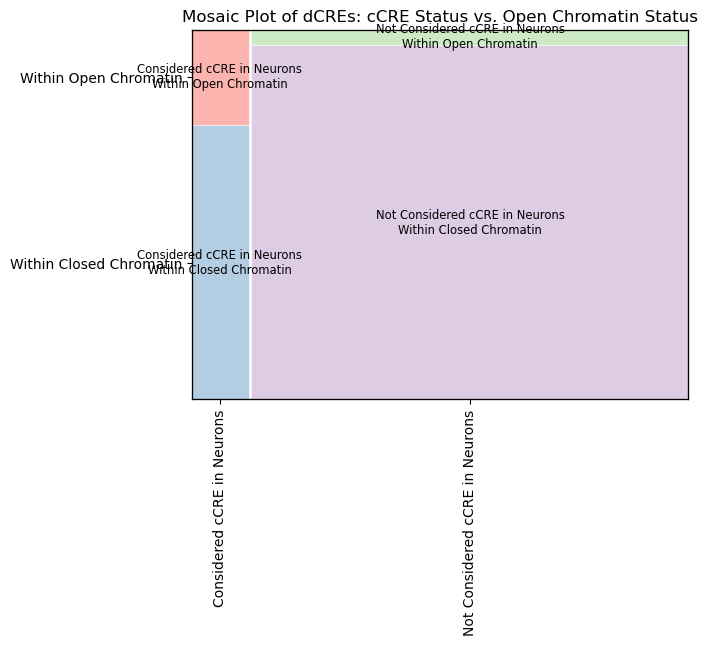

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Dummy DataFrame for demonstration (replace with your actual df_elements_no_alternative_count) ---
# This dummy data ensures the script is runnable for testing purposes.
# data = {
#     'count': [100, 50, 20, 30, 15, 5, 10, 8, 2, 7, 3, 12, 18, 25, 5],
#     'is_dCRE_NGN2': [True, True, True, True, True, True, True, False, False, False, False, True, True, False, False],
#     'is_npc_or_excitatory_SCREEN_cre': [True, False, True, False, True, False, True, False, False, True, False, True, False, True, False],
#     'is_open_NGN2_WTC11_ATAC_1_3_overlap': [True, True, False, False, True, False, True, False, False, True, False, True, False, True, False]
# }
# df_elements_no_alternative_count = pd.DataFrame(data)

# --- Initial Filtering: Start with only dCRE_NGN2 == True sequences ---
# This filters the initial dataset to only include sequences that are
# considered "Significant regulatory sequences" based on is_dCRE_NGN2.
df_initial_set = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True].copy()

# --- Prepare data for Mosaic Plot ---
# The mosaic plot function expects a Series where the index is a MultiIndex
# representing the combinations of categories, and values are the counts.
# We'll use 'is_npc_or_excitatory_SCREEN_cre' and 'is_open_NGN2_WTC11_ATAC_1_3_overlap'
# as the categorical variables.

# Convert boolean columns to more descriptive strings for labels
df_initial_set['SCREEN_Status'] = df_initial_set['is_npc_or_excitatory_SCREEN_cre'].map({True: 'Considered cCRE in Neurons', False: 'Not Considered cCRE in Neurons'})
df_initial_set['Open_Chromatin_Status'] = df_initial_set['is_open_NGN2_WTC11_ATAC_1_3_overlap'].map({True: 'Within Open Chromatin', False: 'Within Closed Chromatin'})

# Group by the new categorical columns and sum the counts
mosaic_data = df_initial_set.groupby(['SCREEN_Status', 'Open_Chromatin_Status'])['count'].sum()

# Define a color map for the plot
# Using a subset of Pastel1 for consistency with previous plots, or a new diverging/qualitative map
cmap = cm.get_cmap('Pastel1')
colors = [cmap(i) for i in [0, 1, 2, 3]] # Select a few distinct colors from Pastel1

# Create a dictionary to map combinations to colors
# This ensures consistent coloring for specific categories
color_map = {
    ('Considered cCRE in Neurons', 'Within Open Chromatin'): mcolors.to_hex(colors[0]),
    ('Considered cCRE in Neurons', 'Within Closed Chromatin'): mcolors.to_hex(colors[1]),
    ('Not Considered cCRE in Neurons', 'Within Open Chromatin'): mcolors.to_hex(colors[2]),
    ('Not Considered cCRE in Neurons', 'Within Closed Chromatin'): mcolors.to_hex(colors[3]),
}

# Function to assign colors based on the combination
def get_color(key):
    # key will be a tuple like ('Considered cCRE in Neurons', 'Within Open Chromatin')
    return {'color': color_map.get(key, 'gray')} # Default to gray if key not found

# --- Create the Mosaic Plot ---
plt.figure(figsize=(10, 7)) # Adjust figure size as needed

# The `properties` argument allows custom styling for each tile
# We use a lambda function to dynamically assign colors based on the combination
mosaic(mosaic_data,
       title='Mosaic Plot of dCREs: cCRE Status vs. Open Chromatin Status',
       gap=0.01, # Gap between tiles
       label_rotation=[90, 0], # Rotate labels for better readability
       properties=get_color
      )

plt.show()


In [73]:
df_elements_no_alternative_count

,is_dCRE_NGN2,bcalm_effect_NGN2,is_npc_or_excitatory_SCREEN_cre,is_npc_or_excitatory_NSC_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_excitatory_neuron_SCREEN_cCRE,is_NPC_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,count
0,False,no_effect,False,False,False,False,False,False,21658
1,False,no_effect,False,False,True,False,False,False,99
2,False,no_effect,False,True,False,False,False,True,442
3,False,no_effect,False,True,True,False,False,True,11
4,False,no_effect,True,True,False,False,True,False,317
5,False,no_effect,True,True,False,False,True,True,627
6,False,no_effect,True,True,False,True,False,False,157
7,False,no_effect,True,True,False,True,False,True,21
8,False,no_effect,True,True,False,True,True,False,9
9,False,no_effect,True,True,False,True,True,True,79


In [74]:
df_elements_no_alternative_count.columns

Index(['is_dCRE_NGN2', 'bcalm_effect_NGN2', 'is_npc_or_excitatory_SCREEN_cre',
       'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_NPC_SCREEN_cCRE',
       'is_neural_stem_SCREEN_cCRE', 'count'],
      dtype='object')

#### Looking into the specific numbers of overlapping dCREs and SCREEN marks: 
Using NPC+NSC+GN SCREEN cCREs 

In [75]:
def print_numbers_overlapping_screen_and_open_chromatin(df_with_screen_and_open_chromatin, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_npc_or_excitatory_NSC_SCREEN_cre', column_is_open_chromatin="is_open_NGN2_WTC11_ATAC_1_3_overlap"):
    """"""
    print("Total dCRE NGN2 sequences:", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE]]['count'].sum())
    print("Number of dCREs which are overlapping SCREEN marks:", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (df_with_screen_and_open_chromatin[column_is_screen])]['count'].sum())
    print("Proportion of dCREs overlapping SCREEN marks:", round(df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (df_with_screen_and_open_chromatin[column_is_screen])]['count'].sum() / df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE]]['count'].sum() * 100, 2), "%")
    if column_is_open_chromatin:
        print("Number of dCREs which are overlapping either open-chromatin or SCREEN marks:", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (df_with_screen_and_open_chromatin[column_is_screen] | df_with_screen_and_open_chromatin[column_is_open_chromatin])]['count'].sum())
        print("Number of dCREs which are overlapping open-chromatin:", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (~df_with_screen_and_open_chromatin[column_is_screen]) & (df_with_screen_and_open_chromatin[column_is_open_chromatin])]['count'].sum())
        print("Proportion of dCREs overlapping open-chromatin marks:", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (~df_with_screen_and_open_chromatin[column_is_screen]) & (df_with_screen_and_open_chromatin[column_is_open_chromatin])]['count'].sum() / df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE]]['count'].sum())
        print("Proportion of dCREs overlapping epigenetic marks: ", df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE] & (df_with_screen_and_open_chromatin[column_is_screen] | df_with_screen_and_open_chromatin[column_is_open_chromatin])]['count'].sum() / df_with_screen_and_open_chromatin.loc[df_with_screen_and_open_chromatin[column_is_dCRE]]['count'].sum())


Only significant regions:

In [76]:
print_numbers_overlapping_screen_and_open_chromatin(df_elements_no_alternative_count, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_npc_or_excitatory_NSC_SCREEN_cre', column_is_open_chromatin="is_open_NGN2_WTC11_ATAC_1_3_overlap")


Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping SCREEN marks: 181
Proportion of dCREs overlapping SCREEN marks: 13.81 %
Number of dCREs which are overlapping either open-chromatin or SCREEN marks: 222
Number of dCREs which are overlapping open-chromatin: 41
Proportion of dCREs overlapping open-chromatin marks: 0.031273836765827616
Proportion of dCREs overlapping epigenetic marks:  0.16933638443935928


Split by activating or repressing effect

In [77]:
df_bcalm_effect_increasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "increasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_increasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_npc_or_excitatory_NSC_SCREEN_cre', column_is_open_chromatin="is_open_NGN2_WTC11_ATAC_1_3_overlap")

Total dCRE NGN2 sequences: 746
Number of dCREs which are overlapping SCREEN marks: 152
Proportion of dCREs overlapping SCREEN marks: 20.38 %
Number of dCREs which are overlapping either open-chromatin or SCREEN marks: 191
Number of dCREs which are overlapping open-chromatin: 39
Proportion of dCREs overlapping open-chromatin marks: 0.05227882037533512
Proportion of dCREs overlapping epigenetic marks:  0.25603217158176944


In [78]:
df_bcalm_effect_decreasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "decreasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_decreasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_npc_or_excitatory_NSC_SCREEN_cre', column_is_open_chromatin="is_open_NGN2_WTC11_ATAC_1_3_overlap")

Total dCRE NGN2 sequences: 565
Number of dCREs which are overlapping SCREEN marks: 29
Proportion of dCREs overlapping SCREEN marks: 5.13 %
Number of dCREs which are overlapping either open-chromatin or SCREEN marks: 31
Number of dCREs which are overlapping open-chromatin: 2
Proportion of dCREs overlapping open-chromatin marks: 0.0035398230088495575
Proportion of dCREs overlapping epigenetic marks:  0.05486725663716814


all regions

In [79]:
df_elements_no_alternative
print("Total Number of sequences tested:", df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre']].shape[0])
print("Proportion of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences additionally in open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'] & (~df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre'])].shape[0])
print("Proportion of sequences additionally in open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'] & (~df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre'])].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with either SCREEN or open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre'] | df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']].shape[0])
print("Proportion of sequences with either SCREEN or open-chromatin marks:",
      df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre'] | df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])

Total Number of sequences tested: 24789
Number of sequences with SCREEN marks: 1902
Proportion of sequences with SCREEN marks: 0.07672758078179838
Number of sequences additionally in open-chromatin marks: 140
Proportion of sequences additionally in open-chromatin marks: 0.0056476663036024045
Number of sequences with either SCREEN or open-chromatin marks: 2042
Proportion of sequences with either SCREEN or open-chromatin marks: 0.08237524708540078


Using GN SCREEN cCREs 

In [80]:
df_elements_no_alternative.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap', 'is_increasing_dCRE_NGN2',
       'is_decreasing_dCRE_NGN2'],
      dtype='object')

In [81]:
# only significant
print_numbers_overlapping_screen_and_open_chromatin(df_elements_no_alternative_count, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_excitatory_neuron_SCREEN_cCRE', column_is_open_chromatin=None)

# Split by activating or repressing effect
print("Increasing: ")
df_bcalm_effect_increasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "increasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_increasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_excitatory_neuron_SCREEN_cCRE', column_is_open_chromatin=None)

print("Decreasing: ")
df_bcalm_effect_decreasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "decreasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_decreasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_excitatory_neuron_SCREEN_cCRE', column_is_open_chromatin=None)

# all regions:
df_elements_no_alternative
print("Total Number of sequences tested:", df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_excitatory_neuron_SCREEN_cCRE']].shape[0])
print("Proportion of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_excitatory_neuron_SCREEN_cCRE']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])

Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping SCREEN marks: 57
Proportion of dCREs overlapping SCREEN marks: 4.35 %
Increasing: 
Total dCRE NGN2 sequences: 746
Number of dCREs which are overlapping SCREEN marks: 53
Proportion of dCREs overlapping SCREEN marks: 7.1 %
Decreasing: 
Total dCRE NGN2 sequences: 565
Number of dCREs which are overlapping SCREEN marks: 4
Proportion of dCREs overlapping SCREEN marks: 0.71 %
Total Number of sequences tested: 24789
Number of sequences with SCREEN marks: 357
Proportion of sequences with SCREEN marks: 0.01440154907418613


Using NPC 

In [82]:
# only significant
print_numbers_overlapping_screen_and_open_chromatin(df_elements_no_alternative_count, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_NPC_SCREEN_cCRE', column_is_open_chromatin=None)

# Split by activating or repressing effect
print("Increasing: ")
df_bcalm_effect_increasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "increasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_increasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_NPC_SCREEN_cCRE', column_is_open_chromatin=None)

print("Decreasing: ")
df_bcalm_effect_decreasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "decreasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_decreasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_NPC_SCREEN_cCRE', column_is_open_chromatin=None)

# all regions:
df_elements_no_alternative
print("Total Number of sequences tested:", df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_NPC_SCREEN_cCRE']].shape[0])
print("Proportion of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_NPC_SCREEN_cCRE']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])

Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping SCREEN marks: 120
Proportion of dCREs overlapping SCREEN marks: 9.15 %
Increasing: 
Total dCRE NGN2 sequences: 746
Number of dCREs which are overlapping SCREEN marks: 104
Proportion of dCREs overlapping SCREEN marks: 13.94 %
Decreasing: 


Total dCRE NGN2 sequences: 565
Number of dCREs which are overlapping SCREEN marks: 16
Proportion of dCREs overlapping SCREEN marks: 2.83 %
Total Number of sequences tested: 24789
Number of sequences with SCREEN marks: 1194
Proportion of sequences with SCREEN marks: 0.048166525475009075


Using neural stem cells

In [83]:
df_elements_no_alternative_count.columns

Index(['is_dCRE_NGN2', 'bcalm_effect_NGN2', 'is_npc_or_excitatory_SCREEN_cre',
       'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_NPC_SCREEN_cCRE',
       'is_neural_stem_SCREEN_cCRE', 'count'],
      dtype='object')

In [84]:
# only significant
print_numbers_overlapping_screen_and_open_chromatin(df_elements_no_alternative_count, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_neural_stem_SCREEN_cCRE', column_is_open_chromatin=None)

# Split by activating or repressing effect
print("Increasing: ")
df_bcalm_effect_increasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "increasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_increasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_neural_stem_SCREEN_cCRE', column_is_open_chromatin=None)

print("Decreasing: ")
df_bcalm_effect_decreasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "decreasing"].copy()
print_numbers_overlapping_screen_and_open_chromatin(df_bcalm_effect_decreasing, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_neural_stem_SCREEN_cCRE', column_is_open_chromatin=None)

# all regions:
df_elements_no_alternative
print("Total Number of sequences tested:", df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_neural_stem_SCREEN_cCRE']].shape[0])
print("Proportion of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_neural_stem_SCREEN_cCRE']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])

Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping SCREEN marks: 124
Proportion of dCREs overlapping SCREEN marks: 9.46 %
Increasing: 
Total dCRE NGN2 sequences: 746
Number of dCREs which are overlapping SCREEN marks: 101
Proportion of dCREs overlapping SCREEN marks: 13.54 %
Decreasing: 
Total dCRE NGN2 sequences: 565
Number of dCREs which are overlapping SCREEN marks: 23
Proportion of dCREs overlapping SCREEN marks: 4.07 %
Total Number of sequences tested: 24789
Number of sequences with SCREEN marks: 1342
Proportion of sequences with SCREEN marks: 0.05413691556738876


#### (old:) Using only NPC+GN SCREEN

In [85]:
print_numbers_overlapping_screen_and_open_chromatin(df_elements_no_alternative_count, column_is_dCRE='is_dCRE_NGN2', column_is_screen='is_npc_or_excitatory_SCREEN_cre', column_is_open_chromatin="is_open_NGN2_WTC11_ATAC_1_3_overlap")

Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping SCREEN marks: 148
Proportion of dCREs overlapping SCREEN marks: 11.29 %
Number of dCREs which are overlapping either open-chromatin or SCREEN marks: 193
Number of dCREs which are overlapping open-chromatin: 45
Proportion of dCREs overlapping open-chromatin marks: 0.034324942791762014
Proportion of dCREs overlapping epigenetic marks:  0.14721586575133486


In [86]:
print("Total dCRE NGN2 sequences:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum())
print("Number of dCREs which are overlapping either open-chromatin or SCREEN marks:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())
print("Number of dCREs which are overlapping SCREEN marks:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum())
print("Number of dCREs which are overlapping open-chromatin:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (~df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre']) & (df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())

print("Proportion of dCREs overlapping SCREEN marks:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum())
print("Proportion of dCREs overlapping open-chromatin marks:", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (~df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre']) & (df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum())
print("Proportion of dCREs overlapping epigenetic marks: ", df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum())



Total dCRE NGN2 sequences: 1311
Number of dCREs which are overlapping either open-chromatin or SCREEN marks: 193
Number of dCREs which are overlapping SCREEN marks: 148
Number of dCREs which are overlapping open-chromatin: 45
Proportion of dCREs overlapping SCREEN marks: 0.11289092295957284
Proportion of dCREs overlapping open-chromatin marks: 0.034324942791762014
Proportion of dCREs overlapping epigenetic marks:  0.14721586575133486


In [87]:
# split by the bcalm effect:
# increasing:
df_bcalm_effect_increasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "increasing"].copy()
print("Total dCRE NGN2 sequences with bcalm effect:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum())
print("Number of increasing dCREs which are overlapping SCREEN marks:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum())
print("Number of increasing dCREs which are overlapping open-chromatin:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (~df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre']) & (df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())
print("Number of increasing dCREs which are overlapping either open-chromatin or SCREEN marks:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())
print("Proportion of increasing dCREs overlapping SCREEN marks:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum())
print("Proportion of increasing dCREs overlapping open-chromatin marks:", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (~df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre']) & (df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum())
print("Proportion of increasing dCREs overlapping epigenetic marks: ", df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum())

# decreasing:
df_bcalm_effect_decreasing = df_elements_no_alternative_count[df_elements_no_alternative_count['bcalm_effect_NGN2'] == "decreasing"].copy()
print("Total dCRE NGN2 sequences with bcalm effect:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum())
print("Number of decreasing dCREs which are overlapping SCREEN marks:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum())
print("Number of decreasing dCREs which are overlapping open-chromatin:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (~df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre']) & (df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())
print("Number of decreasing dCREs which are overlapping either open-chromatin or SCREEN marks:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum())
print("Proportion of decreasing dCREs overlapping SCREEN marks:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum())
print("Proportion of decreasing dCREs overlapping open-chromatin marks:", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (~df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre']) & (df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum())
print("Proportion of decreasing dCREs overlapping epigenetic marks: ", df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum())


Total dCRE NGN2 sequences with bcalm effect: 746
Number of increasing dCREs which are overlapping SCREEN marks: 130
Number of increasing dCREs which are overlapping open-chromatin: 42
Number of increasing dCREs which are overlapping either open-chromatin or SCREEN marks: 172
Proportion of increasing dCREs overlapping SCREEN marks: 0.1742627345844504
Proportion of increasing dCREs overlapping open-chromatin marks: 0.05630026809651475
Proportion of increasing dCREs overlapping epigenetic marks:  0.23056300268096513
Total dCRE NGN2 sequences with bcalm effect: 565
Number of decreasing dCREs which are overlapping SCREEN marks: 18
Number of decreasing dCREs which are overlapping open-chromatin: 3
Number of decreasing dCREs which are overlapping either open-chromatin or SCREEN marks: 21
Proportion of decreasing dCREs overlapping SCREEN marks: 0.03185840707964602
Proportion of decreasing dCREs overlapping open-chromatin marks: 0.005309734513274336
Proportion of decreasing dCREs overlapping ep

In [88]:
df_elements_no_alternative.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap', 'is_increasing_dCRE_NGN2',
       'is_decreasing_dCRE_NGN2'],
      dtype='object')

In [89]:
df_elements_no_alternative.loc[df_elements_no_alternative['is_dCRE_NGN2']]['is_increasing_dCRE_NGN2'].value_counts(normalize=True)

is_increasing_dCRE_NGN2
True     0.569031
False    0.430969
Name: proportion, dtype: float64

In [90]:
df_elements_no_alternative.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap', 'is_increasing_dCRE_NGN2',
       'is_decreasing_dCRE_NGN2'],
      dtype='object')

In [91]:
df_elements_no_alternative
print("Total Number of sequences tested:", df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']].shape[0])
print("Proportion of sequences with SCREEN marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences additionally in open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'] & (~df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'])].shape[0])
print("Proportion of sequences additionally in open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'] & (~df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'])].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])
print("Number of sequences with either SCREEN or open-chromatin marks:", df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']].shape[0])
print("Proportion of sequences with either SCREEN or open-chromatin marks:",
      df_elements_no_alternative.loc[df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']].shape[0] / df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].shape[0])

Total Number of sequences tested: 24789
Number of sequences with SCREEN marks: 1416
Proportion of sequences with SCREEN marks: 0.0571221106135786
Number of sequences additionally in open-chromatin marks: 155
Proportion of sequences additionally in open-chromatin marks: 0.006252773407559805
Number of sequences with either SCREEN or open-chromatin marks: 1571
Proportion of sequences with either SCREEN or open-chromatin marks: 0.0633748840211384


In [92]:
df_elements_no_alternative_tested = df_elements_no_alternative.loc[df_elements_no_alternative['bcalm_data_exists_NGN2']].copy()
df_elements_no_alternative_tested['is_dCRE_NGN2'].value_counts(normalize=True)

is_dCRE_NGN2
False    0.947114
True     0.052886
Name: proportion, dtype: float64

#### Plot the enrichment of sequences with epigenetic annotations

##### Using only glutamatergic/excitatory neurons

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define Odds Ratio Calculation Function
def calculate_odds_ratio(a, b, c, d):
    """
    Calculates the odds ratio from a 2x2 contingency table:
    |           | Outcome+ | Outcome- |
    |-----------+----------+----------|
    | Exposure+ | a        | b        |
    | Exposure- | c        | d        |

    To handle zero counts, 0.5 is added to all cells (Haldane-Anscombe correction)
    which is a common practice for odds ratio calculation in cases of sparse data.
    """
    a_corr, b_corr, c_corr, d_corr = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_exposed = a_corr / b_corr
    odds_unexposed = c_corr / d_corr

    if odds_unexposed == 0:
        return np.inf

    return odds_exposed / odds_unexposed

def compute_and_print_odds_ratios(df, epigenetic_mark_column):
    """
    Computes and prints various odds ratios based on the provided DataFrame
    and the specified epigenetic mark column.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        epigenetic_mark_column (str): The name of the column to use as the epigenetic mark.
    """
    print(f"\n--- Analyzing with Epigenetic Mark: '{epigenetic_mark_column}' ---")

    # Create the combined epigenetic mark column for this run
    df['has_epigenetic_mark'] = df[epigenetic_mark_column]

    # Filter the DataFrame to include only sequences where bcalm_data_exists_NGN2 is True
    df_filtered = df[df['bcalm_data_exists_NGN2']].copy()

    overall_epigenetic_mark = df_filtered['has_epigenetic_mark']
    overall_no_epigenetic_mark = ~df_filtered['has_epigenetic_mark']

    # OR 1: Significant vs. Overall
    is_significant = df_filtered['is_dCRE_NGN2']
    is_non_significant = ~df_filtered['is_dCRE_NGN2']

    a1 = df_filtered[is_significant & overall_epigenetic_mark].shape[0]
    b1 = df_filtered[is_significant & overall_no_epigenetic_mark].shape[0]
    c1 = df_filtered[is_non_significant & overall_epigenetic_mark].shape[0]
    d1 = df_filtered[is_non_significant & overall_no_epigenetic_mark].shape[0]

    odds_ratio_1 = calculate_odds_ratio(a1, b1, c1, d1)
    print(f"\nComputed Odds Ratio (Significant vs. Overall): {odds_ratio_1:.2f}")
    print(f"Contingency Table for OR1:\n| Has Epi | No Epi |\n| Reg: {a1} | {b1} |\n| Non-Reg: {c1} | {d1} |")

    # Filter for only significant sequences for the next ORs
    df_significant = df_filtered[is_significant].copy()
    significant_epigenetic_mark = df_significant['has_epigenetic_mark']
    significant_no_epigenetic_mark = ~df_significant['has_epigenetic_mark']

    # OR 2: Highly Activ vs. Low Activity
    is_increasing_reg = df_significant['is_increasing_dCRE_NGN2']
    is_silencing_reg = df_significant['is_decreasing_dCRE_NGN2']

    a2 = df_significant[is_increasing_reg & significant_epigenetic_mark].shape[0]
    b2 = df_significant[is_increasing_reg & significant_no_epigenetic_mark].shape[0]
    c2 = df_significant[is_silencing_reg & significant_epigenetic_mark].shape[0]
    d2 = df_significant[is_silencing_reg & significant_no_epigenetic_mark].shape[0]

    odds_ratio_2 = calculate_odds_ratio(a2, b2, c2, d2)
    print(f"\nComputed Odds Ratio (Highly Activ vs. Low Activity): {odds_ratio_2:.2f}")
    print(f"Contingency Table for OR2:\n| Has Epi | No Epi |\n| Inc Reg: {a2} | {b2} |\n| Sil Reg: {c2} | {d2} |")

    # OR 3: Highly Activ vs. All Significant
    a3 = df_significant[is_increasing_reg & significant_epigenetic_mark].shape[0]
    b3 = df_significant[is_increasing_reg & significant_no_epigenetic_mark].shape[0]
    c3 = df_significant[significant_epigenetic_mark].shape[0]
    d3 = df_significant[significant_no_epigenetic_mark].shape[0]

    odds_ratio_3 = calculate_odds_ratio(a3, b3, c3, d3)
    print(f"\nComputed Odds Ratio (Highly Activ vs. All Significant): {odds_ratio_3:.2f}")
    print(f"Contingency Table for OR3:\n| Has Epi | No Epi |\n| Inc Reg: {a3} | {b3} |\n| All Reg: {c3} | {d3} |")

    # OR 4: Low Activity vs. All Significant
    a4 = df_significant[is_silencing_reg & significant_epigenetic_mark].shape[0]
    b4 = df_significant[is_silencing_reg & significant_no_epigenetic_mark].shape[0]
    c4 = df_significant[significant_epigenetic_mark].shape[0]
    d4 = df_significant[significant_no_epigenetic_mark].shape[0]

    odds_ratio_4 = calculate_odds_ratio(a4, b4, c4, d4)
    print(f"\nComputed Odds Ratio (Low Activity vs. All Significant): {odds_ratio_4:.2f}")
    print(f"Contingency Table for OR4:\n| Has Epi | No Epi |\n| Sil Reg: {a4} | {b4} |\n| All Reg: {c4} | {d4} |")

    data_all_odds = pd.DataFrame({
        'Comparison': [
            'Activator vs. Repressor',
            'Repressor vs. All Significant',
            'All Significant vs. All CREs',
        ],
        'Odds Ratio': [odds_ratio_2, odds_ratio_4, odds_ratio_1]
    })
    # # for neuro control:
    # data_all_odds = pd.DataFrame({
    #     'Comparison': [
    #         'All Significant vs. All CREs',
    #     ],
    #     'Odds Ratio': [odds_ratio_1]
    # })
    return data_all_odds

def plot_odds_ratios(data_all_odds, title_suffix=""):
    """
    Generates a bar plot of odds ratios.

    Args:
        data_all_odds (pd.DataFrame): DataFrame containing 'Comparison' and 'Odds Ratio' columns.
        title_suffix (str): Additional text to append to the plot title.
    """
    data_all_odds_sorted = data_all_odds.sort_values(by='Odds Ratio', ascending=False).reset_index(drop=True)
    data_all_odds_sorted = data_all_odds

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x='Odds Ratio',
        y='Comparison',
        data=data_all_odds_sorted,
        palette='viridis'
    )

    plt.title(f'Odds Ratios of Epigenetic Marks Across Different Sequence Categories {title_suffix}', fontsize=16)
    plt.xlabel('Odds Ratio', fontsize=12)
    plt.ylabel('Comparison', fontsize=12)

    for index, row in data_all_odds_sorted.iterrows():
        ax.text(row['Odds Ratio'] + 0.1, index, f"{row['Odds Ratio']:.2f}", color='black', ha="left", va="center")
    plt.axvline(1, color='red', linestyle='--', linewidth=0.8, label='No Association (OR=1)')
    # plt.xlim(0, 5.6)
    plt.tight_layout()
    plt.show()


--- Analyzing with Epigenetic Mark: 'is_excitatory_neuron_SCREEN_cCRE' ---

Computed Odds Ratio (Significant vs. Overall): 3.54
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 57 | 1254 |
| Non-Reg: 300 | 23178 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 9.63
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 53 | 693 |
| Sil Reg: 4 | 561 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.68
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 53 | 693 |
| All Reg: 57 | 1254 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.17
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 4 | 561 |
| All Reg: 57 | 1254 |


/tmp/ipykernel_24576/2010094429.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


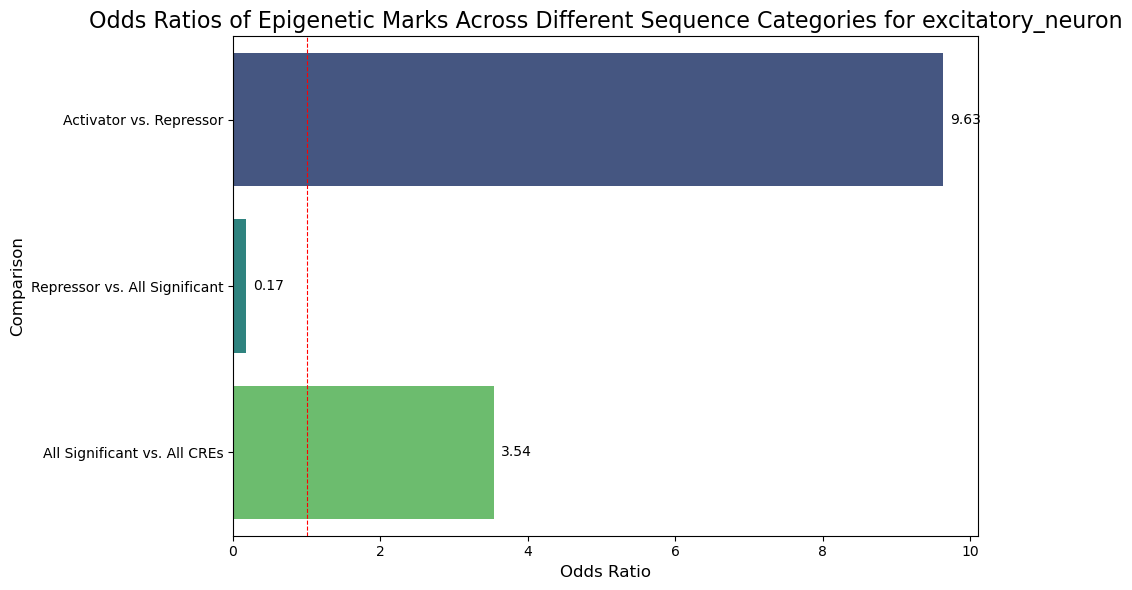


--- Analyzing with Epigenetic Mark: 'is_NPC_SCREEN_cCRE' ---

Computed Odds Ratio (Significant vs. Overall): 2.11
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 120 | 1191 |
| Non-Reg: 1074 | 22404 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 5.42
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 104 | 642 |
| Sil Reg: 16 | 549 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.61
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 104 | 642 |
| All Reg: 120 | 1191 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.30
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 16 | 549 |
| All Reg: 120 | 1191 |


/tmp/ipykernel_24576/2010094429.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


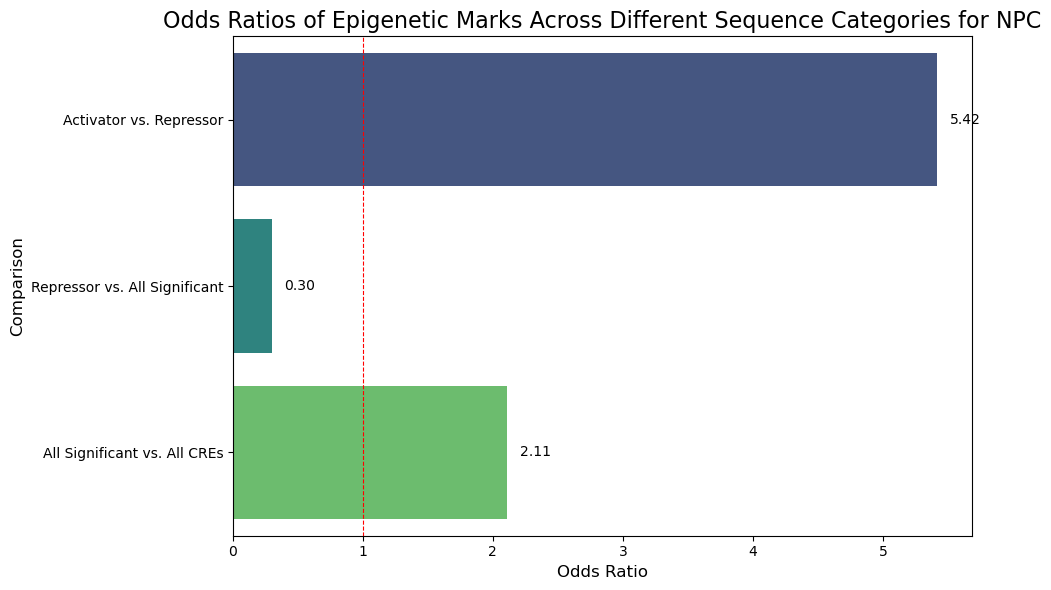


--- Analyzing with Epigenetic Mark: 'is_neural_stem_SCREEN_cCRE' ---

Computed Odds Ratio (Significant vs. Overall): 1.92
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 124 | 1187 |
| Non-Reg: 1218 | 22260 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 3.63
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 101 | 645 |
| Sil Reg: 23 | 542 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.50
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 101 | 645 |
| All Reg: 124 | 1187 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.41
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 23 | 542 |
| All Reg: 124 | 1187 |


/tmp/ipykernel_24576/2010094429.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


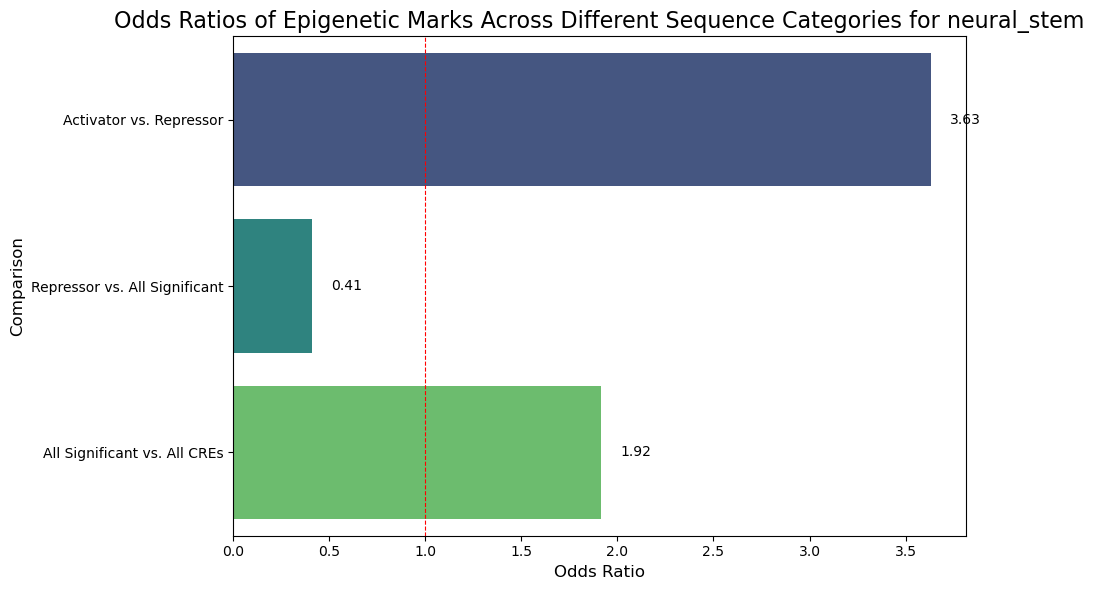


--- Analyzing with Epigenetic Mark: 'is_npc_or_excitatory_NSC_SCREEN_cre' ---

Computed Odds Ratio (Significant vs. Overall): 2.03
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 181 | 1130 |
| Non-Reg: 1721 | 21757 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 4.67
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 152 | 594 |
| Sil Reg: 29 | 536 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.60
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 152 | 594 |
| All Reg: 181 | 1130 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.34
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 29 | 536 |
| All Reg: 181 | 1130 |


/tmp/ipykernel_24576/2010094429.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


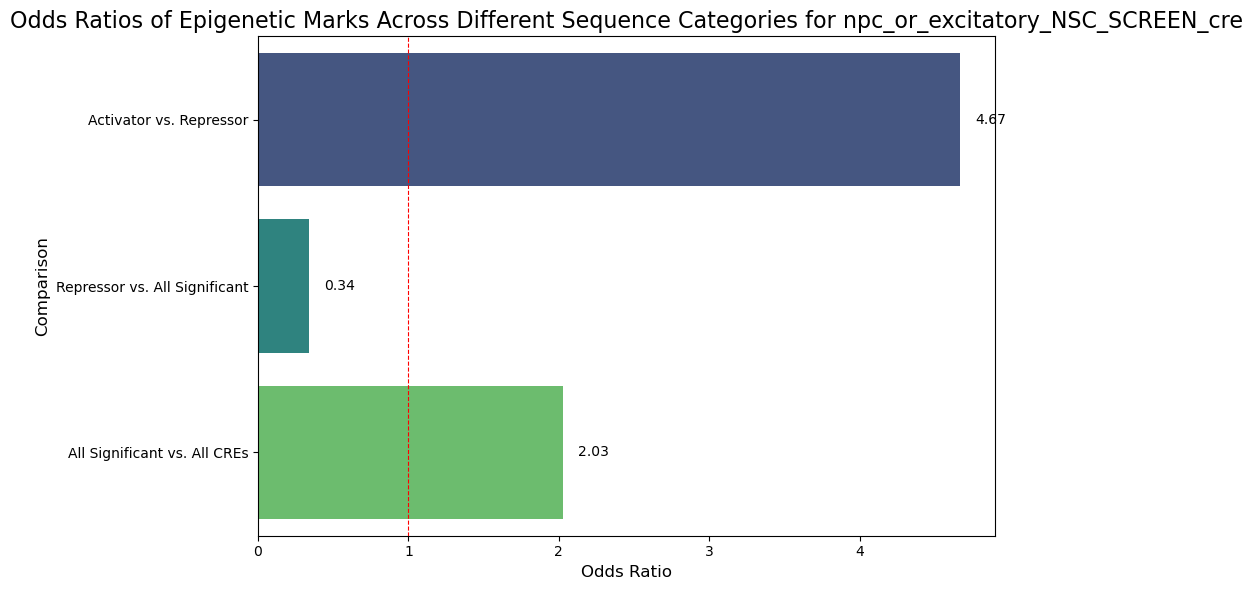


--- Analyzing with Epigenetic Mark: 'is_npc_or_excitatory_SCREEN_cre' ---

Computed Odds Ratio (Significant vs. Overall): 2.23
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 148 | 1163 |
| Non-Reg: 1268 | 22210 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 6.26
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 130 | 616 |
| Sil Reg: 18 | 547 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.66
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 130 | 616 |
| All Reg: 148 | 1163 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.26
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 18 | 547 |
| All Reg: 148 | 1163 |


/tmp/ipykernel_24576/2010094429.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


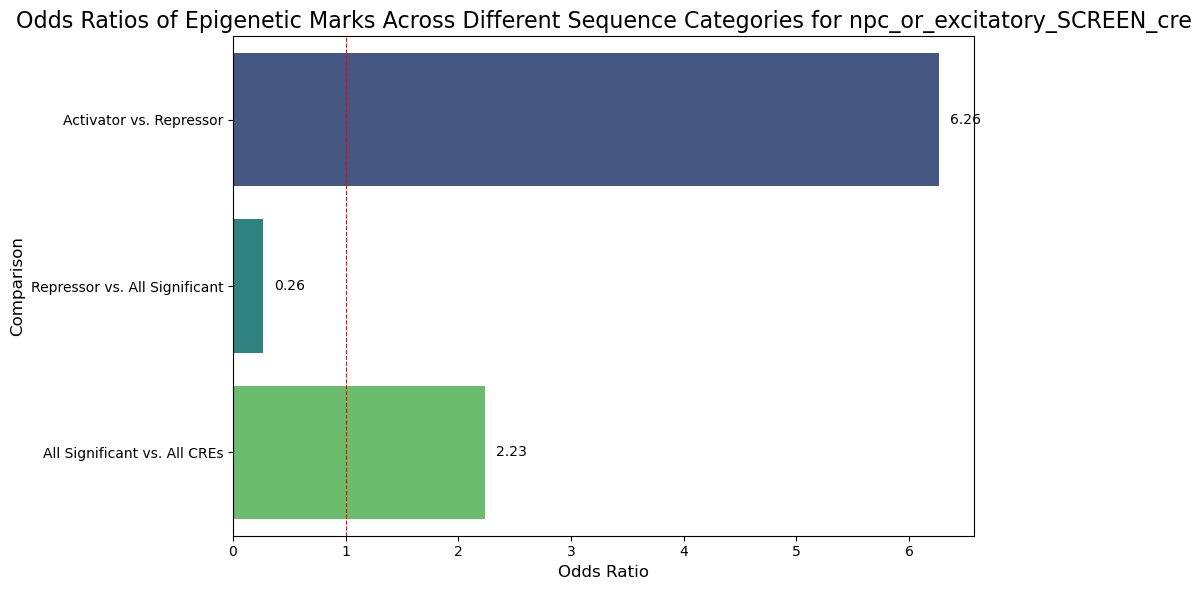

In [94]:
# Define the epigenetic mark columns you want to analyze
epigenetic_mark_columns = [
    'is_excitatory_neuron_SCREEN_cCRE',
    'is_NPC_SCREEN_cCRE',
    'is_neural_stem_SCREEN_cCRE',
    'is_npc_or_excitatory_NSC_SCREEN_cre',
    'is_npc_or_excitatory_SCREEN_cre',
]

for col in epigenetic_mark_columns:
    # Create a deep copy to avoid modifying the original DataFrame in place for each run
    # This is important if `df_elements_no_alternative` is used elsewhere after this loop
    df_copy = df_elements_no_alternative.copy()

    # Compute odds ratios for the current epigenetic mark
    odds_data = compute_and_print_odds_ratios(df_copy, col)

    # Plot the results
    plot_odds_ratios(odds_data, title_suffix=f"for {col.replace('is_', '').replace('_SCREEN_cCRE', '')}")

Using NPC, NSC and glutamatergic/excitatory SCREEN cCREs


Computed Odds Ratio (Significant vs. Overall): 2.02
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 181 | 1130 |
| Non-Reg: 1721 | 21757 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 4.73
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 152 | 594 |
| Sil Reg: 29 | 536 |

Computed Odds Ratio (Highly Activ vs. All Significant): 1.60
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 152 | 594 |
| All Reg: 181 | 1130 |

Computed Odds Ratio (Low Activity vs. All Significant): 0.34
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 29 | 536 |
| All Reg: 181 | 1130 |


/tmp/ipykernel_24576/1561296712.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


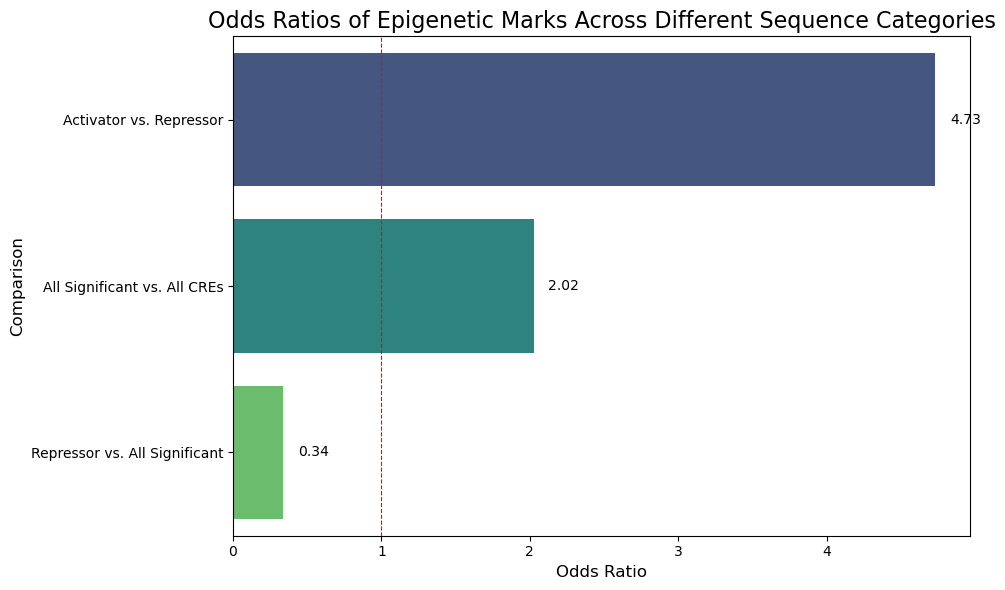

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define Odds Ratio Calculation Function ---
def calculate_odds_ratio(a, b, c, d):
    """
    Calculates the odds ratio from a 2x2 contingency table:
    |           | Outcome+ | Outcome- |
    |-----------+----------+----------|
    | Exposure+ | a        | b        |
    | Exposure- | c        | d        |

    To handle zero counts, 0.5 is added to all cells (Haldane-Anscombe correction)
    which is a common practice for odds ratio calculation in cases of sparse data.
    """
    # a_corr, b_corr, c_corr, d_corr = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    a_corr, b_corr, c_corr, d_corr = a , b , c , d

    odds_exposed = a_corr / b_corr
    odds_unexposed = c_corr / d_corr

    if odds_unexposed == 0:
        return np.inf

    return odds_exposed / odds_unexposed

# # Create the combined epigenetic mark column
# df_elements_no_alternative['has_epigenetic_mark'] = (
#     df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'] |
#     df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']
# )
# # Create the combined epigenetic mark column
# df_elements_no_alternative['has_epigenetic_mark'] = (
#     df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']
# )
# Create the combined epigenetic mark column
df_elements_no_alternative['has_epigenetic_mark'] = (
    df_elements_no_alternative['is_npc_or_excitatory_NSC_SCREEN_cre']
)

# --- 3. Compute Odds Ratios from DataFrame Counts ---

# Filter the DataFrame to include only sequences where bcalm_data_exists_NGN2 is True
df_filtered = df_elements_no_alternative[df_elements_no_alternative['bcalm_data_exists_NGN2']].copy()

# Define the overall epigenetic mark status
overall_epigenetic_mark = df_filtered['has_epigenetic_mark']
overall_no_epigenetic_mark = ~df_filtered['has_epigenetic_mark']

# OR 1: Significant vs. Overall
is_significant = df_filtered['is_dCRE_NGN2']
is_non_significant = ~df_filtered['is_dCRE_NGN2']

a1 = df_filtered[is_significant & overall_epigenetic_mark].shape[0]
b1 = df_filtered[is_significant & overall_no_epigenetic_mark].shape[0]
c1 = df_filtered[is_non_significant & overall_epigenetic_mark].shape[0]
d1 = df_filtered[is_non_significant & overall_no_epigenetic_mark].shape[0]

odds_ratio_1 = calculate_odds_ratio(a1, b1, c1, d1)
print(f"\nComputed Odds Ratio (Significant vs. Overall): {odds_ratio_1:.2f}")
print(f"Contingency Table for OR1:\n| Has Epi | No Epi |\n| Reg: {a1} | {b1} |\n| Non-Reg: {c1} | {d1} |")


# Filter for only significant sequences for the next ORs
df_significant = df_filtered[is_significant].copy()
significant_epigenetic_mark = df_significant['has_epigenetic_mark']
significant_no_epigenetic_mark = ~df_significant['has_epigenetic_mark']


# OR 2: Highly Activ vs. Low Activity
is_increasing_reg = df_significant['is_increasing_dCRE_NGN2']
is_silencing_reg = df_significant['is_decreasing_dCRE_NGN2']

a2 = df_significant[is_increasing_reg & significant_epigenetic_mark].shape[0]
b2 = df_significant[is_increasing_reg & significant_no_epigenetic_mark].shape[0]
c2 = df_significant[is_silencing_reg & significant_epigenetic_mark].shape[0]
d2 = df_significant[is_silencing_reg & significant_no_epigenetic_mark].shape[0]

odds_ratio_2 = calculate_odds_ratio(a2, b2, c2, d2)
print(f"\nComputed Odds Ratio (Highly Activ vs. Low Activity): {odds_ratio_2:.2f}")
print(f"Contingency Table for OR2:\n| Has Epi | No Epi |\n| Inc Reg: {a2} | {b2} |\n| Sil Reg: {c2} | {d2} |")


# OR 3: Highly Activ vs. All Significant
# Note: c3 and d3 represent the total counts for 'All Significant'
a3 = df_significant[is_increasing_reg & significant_epigenetic_mark].shape[0] # Same as a2
b3 = df_significant[is_increasing_reg & significant_no_epigenetic_mark].shape[0] # Same as b2
c3 = df_significant[significant_epigenetic_mark].shape[0] # All significant with epi mark
d3 = df_significant[significant_no_epigenetic_mark].shape[0] # All significant without epi mark

odds_ratio_3 = calculate_odds_ratio(a3, b3, c3, d3)
print(f"\nComputed Odds Ratio (Highly Activ vs. All Significant): {odds_ratio_3:.2f}")
print(f"Contingency Table for OR3:\n| Has Epi | No Epi |\n| Inc Reg: {a3} | {b3} |\n| All Reg: {c3} | {d3} |")


# OR 4: Low Activity vs. All Significant
# Note: c4 and d4 represent the total counts for 'All Significant'
a4 = df_significant[is_silencing_reg & significant_epigenetic_mark].shape[0] # Same as c2 from OR2
b4 = df_significant[is_silencing_reg & significant_no_epigenetic_mark].shape[0] # Same as d2 from OR2
c4 = df_significant[significant_epigenetic_mark].shape[0] # All significant with epi mark (same as c3)
d4 = df_significant[significant_no_epigenetic_mark].shape[0] # All significant without epi mark (same as d3)

odds_ratio_4 = calculate_odds_ratio(a4, b4, c4, d4)
print(f"\nComputed Odds Ratio (Low Activity vs. All Significant): {odds_ratio_4:.2f}")
print(f"Contingency Table for OR4:\n| Has Epi | No Epi |\n| Sil Reg: {a4} | {b4} |\n| All Reg: {c4} | {d4} |")


# --- 4. Prepare Data for Visualization ---

data_all_odds = pd.DataFrame({
    'Comparison': [
        'All Significant vs. All CREs',
        'Activator vs. Repressor',
        'Repressor vs. All Significant'
    ],
    'Odds Ratio': [odds_ratio_1, odds_ratio_2, odds_ratio_4]
})
# data_all_odds = pd.DataFrame({
#     'Comparison': [
#         'significant vs. Overall',
#         'Highly Activ vs. All significant',
#     ],
#     'Odds Ratio': [odds_ratio_1, odds_ratio_3]
# })

# Sort for better visualization
data_all_odds_sorted = data_all_odds.sort_values(by='Odds Ratio', ascending=False).reset_index(drop=True)

# --- 5. Matplotlib and Seaborn Visualization ---
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Odds Ratio',
    y='Comparison',
    data=data_all_odds_sorted,
    palette='viridis'
)

plt.title('Odds Ratios of Epigenetic Marks Across Different Sequence Categories', fontsize=16)
plt.xlabel('Odds Ratio', fontsize=12)
plt.ylabel('Comparison', fontsize=12)

# Add value labels on the bars, using the *new* index from the sorted DataFrame
for index, row in data_all_odds_sorted.iterrows():
    ax.text(row['Odds Ratio'] + 0.1, index, f"{row['Odds Ratio']:.2f}", color='black', ha="left", va="center")

# Add a vertical line at Odds Ratio = 1
plt.axvline(1, color='red', linestyle='--', linewidth=0.8, label='No Association (OR=1)')
# label legend outside the plot
# plt.legend(bbox_to_anchor=(1, 1), fontsize=10)

# plt.xlim(0,6.6)
plt.tight_layout()
plt.show()

In [96]:
1721/ (1721 + 21757)

0.07330266632592214

In [97]:
181/ (1721)

0.10517141196978501

Using NPC and glutamatergic/excitatory SCREEN cCREs


Computed Odds Ratio (Regulatory vs. Overall): 2.23
Contingency Table for OR1:
| Has Epi | No Epi |
| Reg: 148 | 1163 |
| Non-Reg: 1268 | 22210 |

Computed Odds Ratio (Highly Activ vs. Low Activity): 6.26
Contingency Table for OR2:
| Has Epi | No Epi |
| Inc Reg: 130 | 616 |
| Sil Reg: 18 | 547 |

Computed Odds Ratio (Highly Activ vs. All Regulatory): 1.66
Contingency Table for OR3:
| Has Epi | No Epi |
| Inc Reg: 130 | 616 |
| All Reg: 148 | 1163 |

Computed Odds Ratio (Low Activity vs. All Regulatory): 0.26
Contingency Table for OR4:
| Has Epi | No Epi |
| Sil Reg: 18 | 547 |
| All Reg: 148 | 1163 |


/tmp/ipykernel_24576/936415677.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


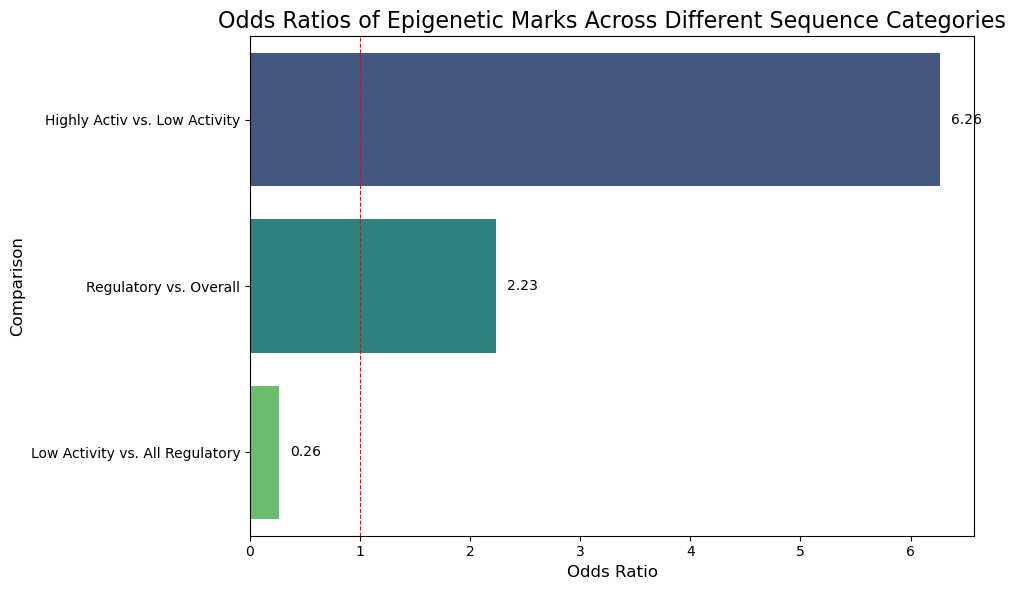

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define Odds Ratio Calculation Function ---

def calculate_odds_ratio(a, b, c, d):
    """
    Calculates the odds ratio from a 2x2 contingency table:
    |           | Outcome+ | Outcome- |
    |-----------+----------+----------|
    | Exposure+ | a        | b        |
    | Exposure- | c        | d        |

    To handle zero counts, 0.5 is added to all cells (Haldane-Anscombe correction)
    which is a common practice for odds ratio calculation in cases of sparse data.
    """
    a_corr, b_corr, c_corr, d_corr = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_exposed = a_corr / b_corr
    odds_unexposed = c_corr / d_corr

    if odds_unexposed == 0:
        return np.inf

    return odds_exposed / odds_unexposed

# # Create the combined epigenetic mark column
# df_elements_no_alternative['has_epigenetic_mark'] = (
#     df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'] |
#     df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']
# )
# Create the combined epigenetic mark column
df_elements_no_alternative['has_epigenetic_mark'] = (
    df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']
)


# --- 3. Compute Odds Ratios from DataFrame Counts ---

# Filter the DataFrame to include only sequences where bcalm_data_exists_NGN2 is True
df_filtered = df_elements_no_alternative[df_elements_no_alternative['bcalm_data_exists_NGN2']].copy()

# Define the overall epigenetic mark status
overall_epigenetic_mark = df_filtered['has_epigenetic_mark']
overall_no_epigenetic_mark = ~df_filtered['has_epigenetic_mark']

# OR 1: Regulatory vs. Overall
is_regulatory = df_filtered['is_dCRE_NGN2']
is_non_regulatory = ~df_filtered['is_dCRE_NGN2']

a1 = df_filtered[is_regulatory & overall_epigenetic_mark].shape[0]
b1 = df_filtered[is_regulatory & overall_no_epigenetic_mark].shape[0]
c1 = df_filtered[is_non_regulatory & overall_epigenetic_mark].shape[0]
d1 = df_filtered[is_non_regulatory & overall_no_epigenetic_mark].shape[0]

odds_ratio_1 = calculate_odds_ratio(a1, b1, c1, d1)
print(f"\nComputed Odds Ratio (Regulatory vs. Overall): {odds_ratio_1:.2f}")
print(f"Contingency Table for OR1:\n| Has Epi | No Epi |\n| Reg: {a1} | {b1} |\n| Non-Reg: {c1} | {d1} |")


# Filter for only regulatory sequences for the next ORs
df_regulatory = df_filtered[is_regulatory].copy()
regulatory_epigenetic_mark = df_regulatory['has_epigenetic_mark']
regulatory_no_epigenetic_mark = ~df_regulatory['has_epigenetic_mark']


# OR 2: Highly Activ vs. Low Activity
is_increasing_reg = df_regulatory['is_increasing_dCRE_NGN2']
is_silencing_reg = df_regulatory['is_decreasing_dCRE_NGN2']

a2 = df_regulatory[is_increasing_reg & regulatory_epigenetic_mark].shape[0]
b2 = df_regulatory[is_increasing_reg & regulatory_no_epigenetic_mark].shape[0]
c2 = df_regulatory[is_silencing_reg & regulatory_epigenetic_mark].shape[0]
d2 = df_regulatory[is_silencing_reg & regulatory_no_epigenetic_mark].shape[0]

odds_ratio_2 = calculate_odds_ratio(a2, b2, c2, d2)
print(f"\nComputed Odds Ratio (Highly Activ vs. Low Activity): {odds_ratio_2:.2f}")
print(f"Contingency Table for OR2:\n| Has Epi | No Epi |\n| Inc Reg: {a2} | {b2} |\n| Sil Reg: {c2} | {d2} |")


# OR 3: Highly Activ vs. All Regulatory
# Note: c3 and d3 represent the total counts for 'All Regulatory'
a3 = df_regulatory[is_increasing_reg & regulatory_epigenetic_mark].shape[0] # Same as a2
b3 = df_regulatory[is_increasing_reg & regulatory_no_epigenetic_mark].shape[0] # Same as b2
c3 = df_regulatory[regulatory_epigenetic_mark].shape[0] # All regulatory with epi mark
d3 = df_regulatory[regulatory_no_epigenetic_mark].shape[0] # All regulatory without epi mark

odds_ratio_3 = calculate_odds_ratio(a3, b3, c3, d3)
print(f"\nComputed Odds Ratio (Highly Activ vs. All Regulatory): {odds_ratio_3:.2f}")
print(f"Contingency Table for OR3:\n| Has Epi | No Epi |\n| Inc Reg: {a3} | {b3} |\n| All Reg: {c3} | {d3} |")


# OR 4: Low Activity vs. All Regulatory
# Note: c4 and d4 represent the total counts for 'All Regulatory'
a4 = df_regulatory[is_silencing_reg & regulatory_epigenetic_mark].shape[0] # Same as c2 from OR2
b4 = df_regulatory[is_silencing_reg & regulatory_no_epigenetic_mark].shape[0] # Same as d2 from OR2
c4 = df_regulatory[regulatory_epigenetic_mark].shape[0] # All regulatory with epi mark (same as c3)
d4 = df_regulatory[regulatory_no_epigenetic_mark].shape[0] # All regulatory without epi mark (same as d3)

odds_ratio_4 = calculate_odds_ratio(a4, b4, c4, d4)
print(f"\nComputed Odds Ratio (Low Activity vs. All Regulatory): {odds_ratio_4:.2f}")
print(f"Contingency Table for OR4:\n| Has Epi | No Epi |\n| Sil Reg: {a4} | {b4} |\n| All Reg: {c4} | {d4} |")


# --- 4. Prepare Data for Visualization ---

data_all_odds = pd.DataFrame({
    'Comparison': [
        'Regulatory vs. Overall',
        'Highly Activ vs. Low Activity',
        'Low Activity vs. All Regulatory'
    ],
    'Odds Ratio': [odds_ratio_1, odds_ratio_2, odds_ratio_4]
})
# data_all_odds = pd.DataFrame({
#     'Comparison': [
#         'Regulatory vs. Overall',
#         'Highly Activ vs. All Regulatory',
#     ],
#     'Odds Ratio': [odds_ratio_1, odds_ratio_3]
# })

# Sort for better visualization
data_all_odds_sorted = data_all_odds.sort_values(by='Odds Ratio', ascending=False).reset_index(drop=True)

# --- 5. Matplotlib and Seaborn Visualization ---

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Odds Ratio',
    y='Comparison',
    data=data_all_odds_sorted,
    palette='viridis'
)

plt.title('Odds Ratios of Epigenetic Marks Across Different Sequence Categories', fontsize=16)
plt.xlabel('Odds Ratio', fontsize=12)
plt.ylabel('Comparison', fontsize=12)

# Add value labels on the bars, using the *new* index from the sorted DataFrame
for index, row in data_all_odds_sorted.iterrows():
    ax.text(row['Odds Ratio'] + 0.1, index, f"{row['Odds Ratio']:.2f}", color='black', ha="left", va="center")

# Add a vertical line at Odds Ratio = 1
plt.axvline(1, color='red', linestyle='--', linewidth=0.8, label='No Association (OR=1)')
# label legend outside the plot
# plt.legend(bbox_to_anchor=(1, 1), fontsize=10)

# plt.xlim(0,6.6)
plt.tight_layout()
plt.show()

In [99]:
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2,is_decreasing_dCRE_NGN2,has_epigenetic_mark
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,decreasing,no_effect,True,False,False,False,False,True,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,no_effect,no_effect,True,False,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,no_effect,no_effect,True,False,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,no_effect,no_effect,True,False,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,no_effect,no_effect,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,no_effect,no_effect,True,False,False,False,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,False,increasing,no_effect,True,False,False,False,True,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,no_effect,no_effect,True,False,False,False,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,no_effect,no_effect,True,False,False,False,False,False,False


In [100]:
asdf

NameError: name 'asdf' is not defined

#### Visualize the proportion of activators and repressors as well as the proportion of 

In [101]:
cre_numbers_ngn2_screen_overlap = {
    'Category': ['Activator', 'Repressor', 'All significant CREs', 'All tested CREs'],
    'Number of CREs': [746, 565, 1311, 24789],
    'Number of CREs with epigenetic marks': [152, 29, 181, 1902],
}
cre_numbers_ngn2_screen_overlap_long = {
    'Category': ['Activator', 'Repressor', 'All significant CREs', 'All tested CREs', 'Activator', 'Repressor', 'All significant CREs', 'All tested CREs'],
    'Number of CREs': [746, 565, 1311, 24789, 152, 29, 181, 1902],
    'Type': ['Total CREs', 'Total CREs', 'Total CREs', 'Total CREs', 'With epigenetic marks', 'With epigenetic marks', 'With epigenetic marks', 'With epigenetic marks'],
}

df_cre_numbers_ngn2_screen_overlap = pd.DataFrame(cre_numbers_ngn2_screen_overlap)
df_cre_numbers_ngn2_screen_overlap['Proportion with epigenetic marks'] = round(df_cre_numbers_ngn2_screen_overlap['Number of CREs with epigenetic marks'] / df_cre_numbers_ngn2_screen_overlap['Number of CREs'] * 100, 3)
df_cre_numbers_ngn2_screen_overlap

,Category,Number of CREs,Number of CREs with epigenetic marks,Proportion with epigenetic marks
0,Activator,746,152,20.375
1,Repressor,565,29,5.133
2,All significant CREs,1311,181,13.806
3,All tested CREs,24789,1902,7.673


Long DataFrame:
               Category  Number of CREs                   Type
0             Activator             746             Total CREs
1             Repressor             565             Total CREs
2  All significant CREs            1311             Total CREs
3       All tested CREs           24789             Total CREs
4             Activator             152  With epigenetic marks
5             Repressor              29  With epigenetic marks
6  All significant CREs             181  With epigenetic marks
7       All tested CREs            1902  With epigenetic marks




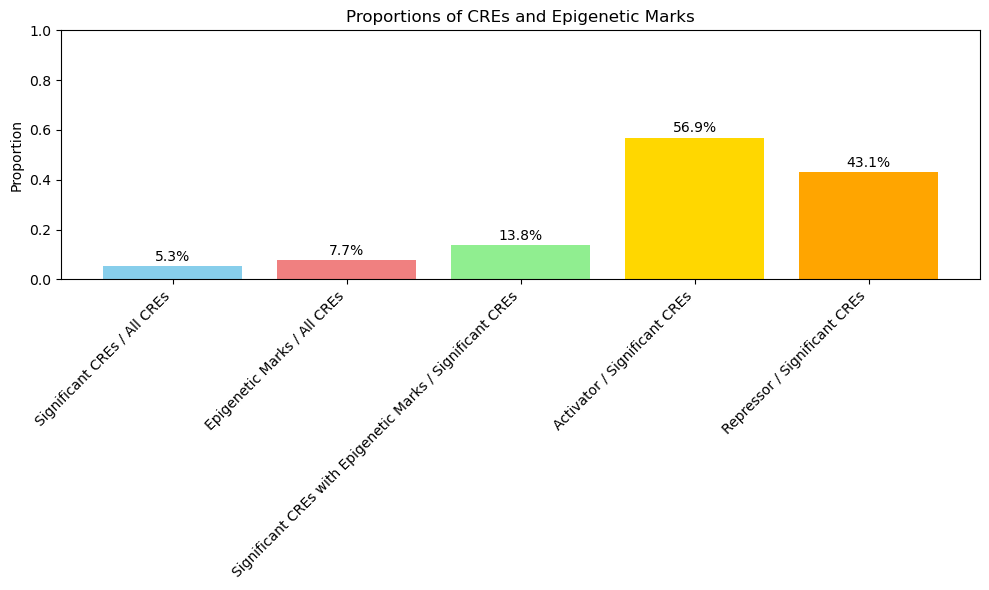

In [102]:
# Create the DataFrame from cre_numbers_ngn2_screen_overlap_long
cre_numbers_ngn2_screen_overlap_long = {
    'Category': ['Activator', 'Repressor', 'All significant CREs', 'All tested CREs', 'Activator', 'Repressor', 'All significant CREs', 'All tested CREs'],
    'Number of CREs': [746, 565, 1311, 24789, 152, 29, 181, 1902],
    'Type': ['Total CREs', 'Total CREs', 'Total CREs', 'Total CREs', 'With epigenetic marks', 'With epigenetic marks', 'With epigenetic marks', 'With epigenetic marks'],
}
df_long = pd.DataFrame(cre_numbers_ngn2_screen_overlap_long)
print("Long DataFrame:")
print(df_long)
print("\n")
# Calculate the proportions for plotting
# Bar 1: Proportion of significant CREs for all CREs.
all_significant_cre = df_long[(df_long['Category'] == 'All significant CREs') & (df_long['Type'] == 'Total CREs')]['Number of CREs'].iloc[0]
all_tested_cre = df_long[(df_long['Category'] == 'All tested CREs') & (df_long['Type'] == 'Total CREs')]['Number of CREs'].iloc[0]
prop_significant_of_all = all_significant_cre / all_tested_cre

# Bar 2: Proportion of cCREs with epigenetic marks for all CREs.
all_tested_cre_epigenetic = df_long[(df_long['Category'] == 'All tested CREs') & (df_long['Type'] == 'With epigenetic marks')]['Number of CREs'].iloc[0]
prop_epigenetic_of_all = all_tested_cre_epigenetic / all_tested_cre

# Bar 3: Proportion of significant CREs with epigenetic marks (only for significant CREs).
all_significant_cre_epigenetic = df_long[(df_long['Category'] == 'All significant CREs') & (df_long['Type'] == 'With epigenetic marks')]['Number of CREs'].iloc[0]
prop_epigenetic_of_significant = all_significant_cre_epigenetic / all_significant_cre

# Bar 4: Percentage between activator and repressor of the significant results
activator_significant = df_long[(df_long['Category'] == 'Activator') & (df_long['Type'] == 'Total CREs')]['Number of CREs'].iloc[0]
repressor_significant = df_long[(df_long['Category'] == 'Repressor') & (df_long['Type'] == 'Total CREs')]['Number of CREs'].iloc[0]
total_significant = activator_significant + repressor_significant # Should be 1311
prop_activator_of_significant = activator_significant / total_significant
prop_repressor_of_significant = repressor_significant / total_significant

# Prepare data for plotting
labels = [
    'Significant CREs / All CREs',
    'Epigenetic Marks / All CREs',
    'Significant CREs with Epigenetic Marks / Significant CREs',
    'Activator / Significant CREs',
    'Repressor / Significant CREs'
]
proportions = [
    prop_significant_of_all,
    prop_epigenetic_of_all,
    prop_epigenetic_of_significant,
    prop_activator_of_significant,
    prop_repressor_of_significant
]

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, proportions, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orange'])

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.1%}', ha='center', va='bottom')

ax.set_ylabel('Proportion')
ax.set_title('Proportions of CREs and Epigenetic Marks')
ax.set_ylim(0, 1) # Proportions are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [103]:
print(df_cre_numbers_ngn2_screen_overlap)

               Category  Number of CREs  Number of CREs with epigenetic marks  \
0             Activator             746                                   152   
1             Repressor             565                                    29   
2  All significant CREs            1311                                   181   
3       All tested CREs           24789                                  1902   

   Proportion with epigenetic marks  
0                            20.375  
1                             5.133  
2                            13.806  
3                             7.673  


/tmp/ipykernel_24576/1305926481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Proportion with epigenetic marks', data=df_cre_numbers_ngn2_screen_overlap, palette='viridis')


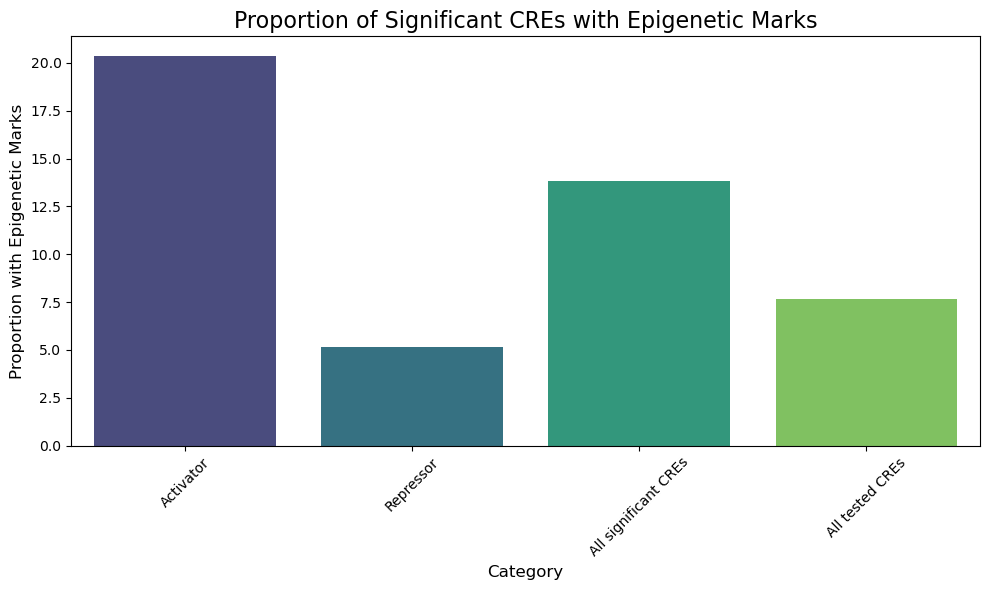

In [104]:
# plot the proportion of significant CREs
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Proportion with epigenetic marks', data=df_cre_numbers_ngn2_screen_overlap, palette='viridis')
plt.title('Proportion of Significant CREs with Epigenetic Marks', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Proportion with Epigenetic Marks', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Investigate the range of the activators and repressors of the negative neuro control and scramble control results

In [105]:
df_elements_all_regions_scramble_control = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_combined'], sep='\t')
# df_elements_all_regions_neuro_control = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_combined_neuro_ctrl'], sep='\t', low_memory=False)
df_elements_all_regions_neuro_control = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_with_annotation_groups_combined_neuro_ctrl'], sep='\t', low_memory=False)

In [106]:
df_elements_all_regions_neuro_control.columns


Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

In [107]:
df_elements_all_regions_scramble_control.columns
df_elements_all_regions_scramble_control = df_elements_all_regions_scramble_control.loc[df_elements_all_regions_scramble_control['bcalm_data_exists_NGN2']].copy()
# rename the columns: raw_activity_NGN2_log2FC_bcalm, bcalm_adj_p_NGN2, is_dCRE_NGN2
df_elements_all_regions_scramble_control = df_elements_all_regions_scramble_control.rename(columns={
    'raw_activity_NGN2_log2FC_bcalm': 'raw_activity_NGN2_log2FC_scrambled_ctrl',
    'bcalm_adj_p_NGN2': 'bcalm_adj_p_NGN2_scrambled_ctrl',
    'is_dCRE_NGN2': 'is_dCRE_NGN2_scrambled_ctrl'
})

In [108]:
df_elements_all_regions_neuro_scramble_ctrl = df_elements_all_regions_neuro_control.merge(df_elements_all_regions_scramble_control[[col_name, 'raw_activity_NGN2_log2FC_scrambled_ctrl', 'bcalm_adj_p_NGN2_scrambled_ctrl', 'is_dCRE_NGN2_scrambled_ctrl']], on=col_name, how='left')
df_elements_all_regions_neuro_scramble_ctrl

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_npc_or_NSC_SCREEN_cre,is_npc_or_excitatory_NSC_SCREEN_cre,is_excitatory_or_NSC_SCREEN_cre,raw_activity_NGN2_log2FC_scrambled_ctrl,bcalm_adj_p_NGN2_scrambled_ctrl,is_dCRE_NGN2_scrambled_ctrl
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,1.000000e+00,-1.928542,...,no_effect,no_effect,True,False,False,False,False,-0.089726,2.492488e-03,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,no_effect,no_effect,True,False,False,False,False,-0.026591,1.000000e+00,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,no_effect,no_effect,True,False,False,False,False,-0.033114,1.000000e+00,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,no_effect,no_effect,True,False,False,False,False,-0.018290,1.000000e+00,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149.0,70277419.0,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,no_effect,no_effect,True,False,False,False,False,-0.038026,1.000000e+00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,no_effect,no_effect,True,False,False,False,False,-0.076844,1.000000e+00,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116.0,107008386.0,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,1.641708e-32,3.966275,...,increasing,no_effect,True,False,False,False,False,0.138223,8.599369e-22,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,2.456195e-04,1.804262,...,increasing,no_effect,True,False,False,False,False,0.054619,3.581264e-01,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939.0,107039209.0,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,no_effect,no_effect,True,False,False,False,False,-0.064615,1.000000e+00,False


In [109]:
# compute the correlation between raw_activity_NGN2_log2FC_scrambled_ctrl and raw_activity_NGN2_log2FC_bcalm
correlation = df_elements_all_regions_neuro_scramble_ctrl['raw_activity_NGN2_log2FC_scrambled_ctrl'].corr(df_elements_all_regions_neuro_scramble_ctrl['raw_activity_NGN2_log2FC_bcalm'])
print(f"Correlation between scrambled and neuro ctrl raw activity: {correlation:.2f}")
correlation = df_elements_all_regions_neuro_scramble_ctrl['bcalm_adj_p_NGN2_scrambled_ctrl'].corr(df_elements_all_regions_neuro_scramble_ctrl['bcalm_adj_p_NGN2'])
print(f"Correlation between scrambled and neuro ctrl adjusted p-value: {correlation:.2f}")

Correlation between scrambled and neuro ctrl raw activity: 1.00
Correlation between scrambled and neuro ctrl adjusted p-value: 0.30


In [110]:
# check the activity range of the scrambled control:
df_elements_all_regions_neuro_scramble_ctrl_readout = df_elements_all_regions_neuro_scramble_ctrl.loc[df_elements_all_regions_neuro_scramble_ctrl['bcalm_data_exists_NGN2']].copy()

sig_level = 0.05
# significant according to scrambled control:
((df_elements_all_regions_neuro_scramble_ctrl_readout['bcalm_adj_p_NGN2_scrambled_ctrl'] < sig_level) & (df_elements_all_regions_neuro_scramble_ctrl_readout['is_dCRE_NGN2_scrambled_ctrl']) ).sum()


3761

In [111]:
df_elements_all_regions_neuro_scramble_ctrl.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

In [112]:
df_elements_all_regions_neuro_scramble_ctrl_readout.loc[df_elements_all_regions_neuro_scramble_ctrl_readout['is_dCRE_NGN2_scrambled_ctrl']]['raw_activity_NGN2_log2FC_bcalm'].min()
df_elements_all_regions_neuro_scramble_ctrl_readout.loc[df_elements_all_regions_neuro_scramble_ctrl_readout['is_dCRE_NGN2_scrambled_ctrl']]['normalized_activity_NGN2'].min()

-3.734205611275136

In [130]:
# write
writing = False
if writing:
    # df_elements_all_regions_neuro_scramble_ctrl_readout.to_csv(config['files']['creating']['ngn2_80k_mpra_screen_annotation'], sep='\t', index=False)
    df_elements_all_regions_neuro_scramble_ctrl_readout.to_csv("/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/ngn2_80k_mpra_all_sequences_with_readouts_screen_info_annotation_2509.tsv.gz", sep='\t', index=False)

#### Plot the CREs vs the scrambled controls

In [ ]:
df_elements_with_scrambled = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled'], sep='\t')


/tmp/ipykernel_24576/2609078050.py:1: DtypeWarning: Columns (4,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_elements_with_scrambled = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled'], sep='\t')


In [114]:
import ast
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# add label column
def add_label_column(name):
    """Add either scrambled or tested or not_important_for_cell_type_comparison label to the name"""
    if "scramble" in name:
        return "scrambled"
    elif "cardiac_neuro_cava_random" in name:
        return "tested"
    else:
        return "not_important_for_cell_type_comparison"


# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x



# Apply the safe_eval function to the specified columns
for col in list_columns:
    df_elements_with_scrambled[col] = df_elements_with_scrambled[col].apply(safe_eval)

df_elements_with_scrambled['label'] = df_elements_with_scrambled['name'].apply(add_label_column)
df_elements_with_scrambled = df_elements_with_scrambled.loc[df_elements_with_scrambled['bcalm_data_exists']].copy()

In [115]:
df_elements_with_scrambled.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [116]:
df_elements_with_scrambled['label'].value_counts()

label
tested                                    68241
not_important_for_cell_type_comparison     4950
scrambled                                   496
Name: count, dtype: int64

In [117]:
# df_elements_with_scrambled_filtered = df_elements_with_scrambled.loc[df_elements_with_scrambled['name'].str.contains("scramb")].copy()
df_elements_with_scrambled_filtered = df_elements_with_scrambled.loc[df_elements_with_scrambled['label'].isin(['tested', 'scrambled'])].copy()
df_elements_with_scrambled_filtered.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [118]:
df_elements_with_scrambled_filtered_no_alternative = df_elements_with_scrambled_filtered.loc[(~df_elements_with_scrambled_filtered['name'].str.contains('cardiac_neuro_cava_random:ALT_')) | (df_elements_with_scrambled_filtered['label'] == 'scrambled')].copy()

In [119]:
df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()

label
tested       25578
scrambled      496
Name: count, dtype: int64

In [120]:
df_elements_with_scrambled_filtered_no_alternative.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [121]:
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_NSC_SCREEN_cre,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2,is_decreasing_dCRE_NGN2,has_epigenetic_mark
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,decreasing,no_effect,True,False,False,False,False,True,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,no_effect,no_effect,True,False,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,no_effect,no_effect,True,False,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,no_effect,no_effect,True,False,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,no_effect,no_effect,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,no_effect,no_effect,True,False,False,False,False,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,False,increasing,no_effect,True,False,False,False,True,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,no_effect,no_effect,True,False,False,False,False,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,no_effect,no_effect,True,False,False,False,False,False,False


In [ ]:
df_elements_all_regions_neuro_scramble_ctrl_readout.columns
columns_for_screen_annotation = ['sequence', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE' 'is_npc_or_excitatory_NSC_SCREEN_cre']

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

In [138]:
df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()

label
tested       25578
scrambled      496
Name: count, dtype: int64

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

tested vs. scrambled: Mann-Whitney-Wilcoxon test two-sided, P_val:4.499e-03 U_stat=6.815e+06


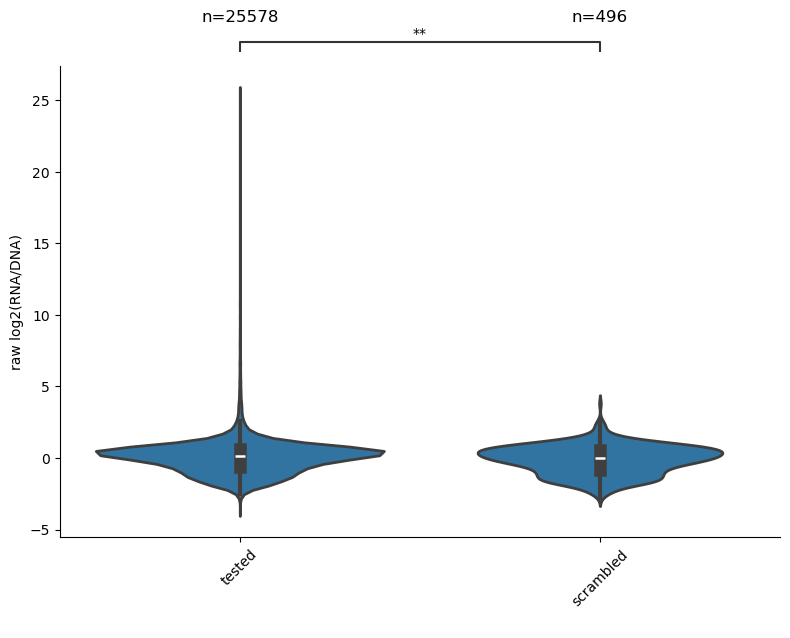

In [122]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
import seaborn as sns
y_axis_col = "not_shifted_bcalm_element_log_ratio_activity"
y_axis_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=df_elements_with_scrambled_filtered_no_alternative, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('tested', 'scrambled')], data=df_elements_with_scrambled_filtered_no_alternative, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# # annotate with the number of sequences in each group (for not_shifted activity)
# ax.text(0, 1.3, f"n={df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()['tested']}", ha='center', va='center', fontsize=12)
# ax.text(1, 1.3, f"n={df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()['scrambled']}", ha='center', va='center', fontsize=12)
# annotate with the number of sequences in each group (for normalized activity)
ax.text(0, 30.8, f"n={df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()['tested']}", ha='center', va='center', fontsize=12)
ax.text(1, 30.8, f"n={df_elements_with_scrambled_filtered_no_alternative['label'].value_counts()['scrambled']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

In [123]:
asdf

NameError: name 'asdf' is not defined

Using only elements with CREs

In [132]:
df_elements_all_regions_neuro_scramble_ctrl_readout.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

In [136]:
df_elements_all_regions_neuro_scramble_ctrl_readout['is_H9_SCREEN_cCRE'].isna().sum()

0

In [149]:
df_elements_with_scrambled_filtered_no_alternative_screen_info = df_elements_with_scrambled_filtered_no_alternative.merge(df_elements_all_regions_neuro_scramble_ctrl_readout[['sequence', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE', 'is_npc_or_excitatory_NSC_SCREEN_cre']], on=col_sequence, how='left')
df_elements_with_scrambled_filtered_no_alternative_screen_info
# scambled sequences do not get annotated
# df_elements_with_scrambled_filtered_no_alternative_screen_info['is_H9_SCREEN_cCRE'].isna().sum()

,name,sequence,category,class,source,ref,chr,start,end,strand,...,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_npc_or_excitatory_NSC_SCREEN_cre
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,tested,-0.074506,0.255056,-1.534950,False,False,False,False,False,False
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,tested,0.024747,3.065142,1.031757,False,False,False,False,False,False
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,tested,0.058800,4.029274,1.912386,False,False,False,False,False,False
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,tested,-0.071544,0.338923,-1.458346,False,False,False,False,False,False
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,tested,-0.044408,1.107215,-0.756596,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26069,MK:tile_24954|chr2-236620899+236621168|scrambl...,GAAGCTAGCTCTAGGTGAAGTCCATAATATGAGGGCATGACAGTAG...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,scrambled,0.006845,2.558311,0.568822,NaN,NaN,NaN,NaN,NaN,NaN
26070,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,scrambled,-0.034812,1.378888,-0.508452,NaN,NaN,NaN,NaN,NaN,NaN
26071,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,scrambled,-0.053084,0.861566,-0.980968,NaN,NaN,NaN,NaN,NaN,NaN
26072,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,scrambled,-0.003913,2.253734,0.290624,NaN,NaN,NaN,NaN,NaN,NaN


In [140]:
df_elements_with_scrambled_filtered_no_alternative_screen_info.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE',
       'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE',
       'is_npc_or_excitatory_NSC_SCREEN_cre'],
      dtype='object')

In [ ]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
import seaborn as sns
y_axis_col = "not_shifted_bcalm_element_log_ratio_activity"
y_axis_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=df_elements_with_scrambled_filtered_no_alternative_screen_info, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('tested', 'scrambled')], data=df_elements_with_scrambled_filtered_no_alternative_screen_info, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# # annotate with the number of sequences in each group (for not_shifted activity)
# ax.text(0, 1.3, f"n={df_elements_with_scrambled_filtered_no_alternative_screen_info['label'].value_counts()['tested']}", ha='center', va='center', fontsize=12)
# ax.text(1, 1.3, f"n={df_elements_with_scrambled_filtered_no_alternative_screen_info['label'].value_counts()['scrambled']}", ha='center', va='center', fontsize=12)
# annotate with the number of sequences in each group (for normalized activity)
ax.text(0, 30.8, f"n={df_elements_with_scrambled_filtered_no_alternative_screen_info['label'].value_counts()['tested']}", ha='center', va='center', fontsize=12)
ax.text(1, 30.8, f"n={df_elements_with_scrambled_filtered_no_alternative_screen_info['label'].value_counts()['scrambled']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_activity_with_subset(df, y_axis_col, subset_col):
    """
    Generates violin plots for three groups: 'tested' (including subset), 'scrambled', and a subset of 'tested'.

    Args:
        df (pd.DataFrame): The input DataFrame.
        y_axis_col (str): The name of the column for the y-axis (activity).
        subset_col (str): The name of the column that defines the subset (e.g., 'is_npc_or_excitatory_NSC_SCREEN_cre').
    """

    # Calculate the max y-value from the entire dataset for consistent annotation positioning
    y_max_all = df[y_axis_col].max()

    # Filter data into the three distinct groups
    tested_data = df.loc[df['label'] == 'tested', y_axis_col].values
    scrambled_data = df.loc[df['label'] == 'scrambled', y_axis_col].values
    subset_tested_data = df.loc[(df['label'] == 'tested') & (df[subset_col] == True), y_axis_col].values

    # Create a list of the data to plot
    data_to_plot = [tested_data, scrambled_data, subset_tested_data]

    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all three groups in a single call, passing the list of arrays
    sns.violinplot(data=data_to_plot, ax=ax, inner='box', linewidth=2, palette='viridis')

    # Get counts for annotation
    tested_count = len(tested_data)
    scrambled_count = len(scrambled_data)
    subset_tested_count = len(subset_tested_data)

    # Annotate with the number of sequences in each group
    # Use the calculated max value to position the text
    ax.text(0, y_max_all * 1.05, f"n={tested_count}", ha='center', va='center', fontsize=12)
    ax.text(1, y_max_all * 1.05, f"n={scrambled_count}", ha='center', va='center', fontsize=12)
    ax.text(2, y_max_all * 1.05, f"n={subset_tested_count}", ha='center', va='center', fontsize=12)

    # Set x-axis tick labels
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(['tested', 'scrambled', 'NPC, NSC or neuron'], rotation=45)

    # Set axis labels and title
    ax.set_xlabel(' ')
    ax.set_ylabel('log2(RNA/DNA)')
    plt.title('Violin Plot with Subset of Data Included')

    # Remove the top and right spines from the plot
    sns.despine()

    plt.tight_layout()
    plt.show()

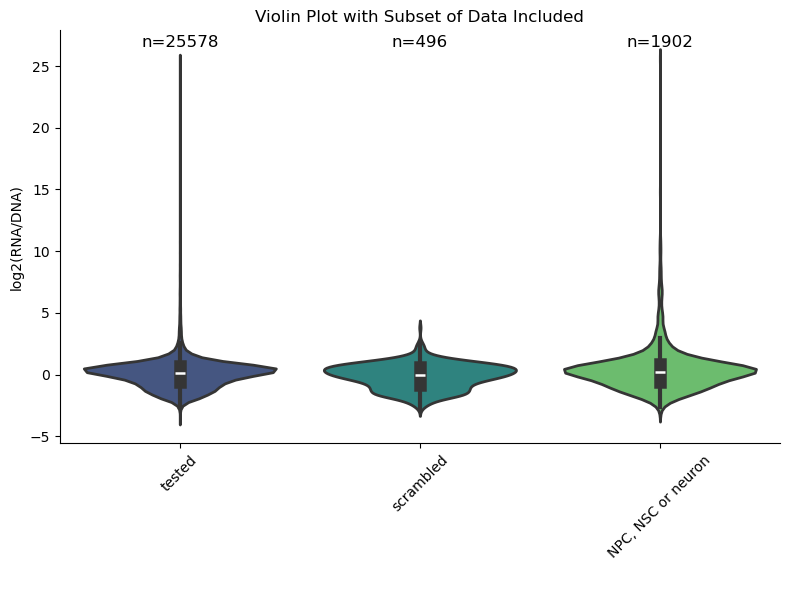

In [146]:
plot_activity_with_subset(
    df_elements_with_scrambled_filtered_no_alternative_screen_info,
    y_axis_col="bcalm_element_log_ratio_activity_z_score_scrambled_ctrl",
    subset_col="is_npc_or_excitatory_NSC_SCREEN_cre"
)

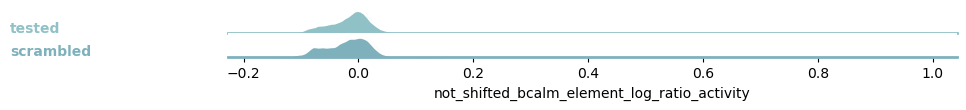

In [ ]:
# plot the regions vs the scrambled controls
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_activity_group"
plot_name_col = "label"
plot_value_col = "bcalm_element_log_ratio_activity"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
plot_value_col = "logFC"
plot_value_col = "not_shifted_bcalm_element_log_ratio_activity"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df_elements_with_scrambled_filtered_no_alternative, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.3, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.02)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

In [160]:
#how many annotated sequences => good candidates for showing acual activity in the cell-type are among the actives and how many are not
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info = df_elements_with_scrambled_filtered_no_alternative_screen_info.loc[df_elements_with_scrambled_filtered_no_alternative_screen_info['label'] == 'tested'].copy()
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info['is_npc_or_excitatory_NSC_SCREEN_cre'].value_counts()

tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info['is_significantly_different_scrambled_ctrl'] = (tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info['bcalm_element_adjusted_p_value'] < 0.05)
# Filter the DataFrame to include only rows where the sequence is true
df_filtered = tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info[tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info['is_npc_or_excitatory_NSC_SCREEN_cre'] == True].copy()


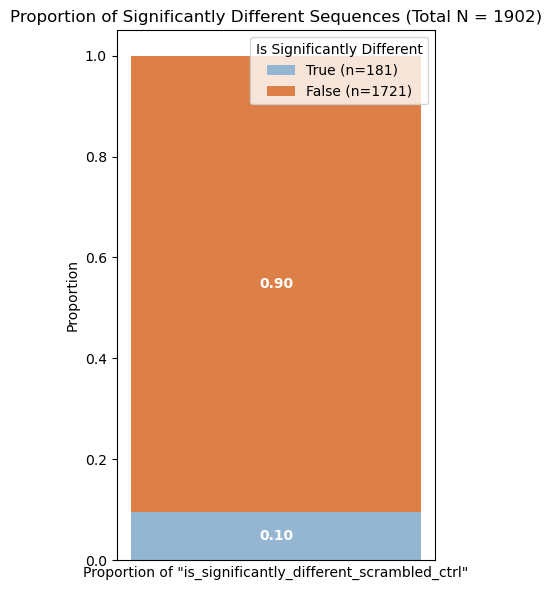

Total number of sequences analyzed (N): 1902

Proportions of significantly different sequences:
is_significantly_different_scrambled_ctrl
False    0.904837
True     0.095163
Name: count, dtype: float64


In [163]:

# Calculate the counts and total for the two groups
counts = df_filtered['is_significantly_different_scrambled_ctrl'].value_counts()
total_n = len(df_filtered)

# Calculate the proportions
proportions = counts / total_n

# Set up the stacked bar plot
plt.figure(figsize=(4, 6))

# Define custom colors
colors = {'True': '#94B6D2', 'False': '#DD8047'}

# Get the proportion and count for True and False values
prop_true = proportions.get(True, 0)
prop_false = proportions.get(False, 0)
count_true = counts.get(True, 0)
count_false = counts.get(False, 0)

# Plot the stacked bars with a tighter width
bar_width = 0.03
plt.bar(x=0, height=prop_true, color=colors['True'], label=f'True (n={count_true})', width=bar_width)
plt.bar(x=0, height=prop_false, bottom=prop_true, color=colors['False'], label=f'False (n={count_false})', width=bar_width)

# Add labels and a title to the plot
plt.xlabel('Proportion of "is_significantly_different_scrambled_ctrl"')
plt.ylabel('Proportion')
plt.title(f'Proportion of Significantly Different Sequences (Total N = {total_n})')

# Annotate each segment with its proportion value
plt.text(0, prop_true / 2, f'{prop_true:.2f}', ha='center', va='center', color='white', fontweight='bold')
plt.text(0, prop_true + (prop_false / 2), f'{prop_false:.2f}', ha='center', va='center', color='white', fontweight='bold')

# Set the x-axis tick to 0 and remove tick labels
plt.xticks([])

# Add a legend to explain the colors and counts
plt.legend(title='Is Significantly Different', loc='upper right')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()

# Print the results to the console
print(f"Total number of sequences analyzed (N): {total_n}")
print("\nProportions of significantly different sequences:")
print(proportions)

In [164]:
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info['is_significantly_different_scrambled_ctrl'].value_counts()

is_significantly_different_scrambled_ctrl
False    24220
True      1358
Name: count, dtype: int64

In [167]:
writing=False
if writing:
    tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info.to_csv("/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/ngn2_80k_no_alternative_normalized_scrambled_activity_screen_info.tsv.gz", sep='\t', index=False)

In [ ]:
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info

In [165]:
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info.groupby('is_npc_or_excitatory_NSC_SCREEN_cre')['is_significantly_different_scrambled_ctrl'].value_counts()

is_npc_or_excitatory_NSC_SCREEN_cre  is_significantly_different_scrambled_ctrl
False                                False                                        22499
                                     True                                          1177
True                                 False                                         1721
                                     True                                           181
Name: count, dtype: int64

In [156]:
tesed_df_elements_with_scrambled_filtered_no_alternative_screen_info.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE',
       'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE',
       'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_significantly_different_scrambled_ctrl'],
      dtype='object')

In [ ]:
# # generate table with the counts of dCREs overlapping epigenetic marks and SCREEN marks
# df_counts = pd.DataFrame({
#     'Total dCRE NGN2 sequences': [df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum()],
#     'Overlapping SCREEN marks': [df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum()],
#     'Overlapping epigenetic marks': [df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum()],
#     'Proportion overlapping SCREEN marks': [df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum()],
#     'Proportion overlapping epigenetic marks': [df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2'] & (df_elements_no_alternative_count['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative_count['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_elements_no_alternative_count.loc[df_elements_no_alternative_count['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Increasing Total': [df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Increasing Overlapping SCREEN marks': [df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum()],
#     'Bcalm Effect Increasing Overlapping epigenetic marks': [df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum()],
#     'Bcalm Effect Increasing Proportion Overlapping SCREEN marks': [df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Increasing Proportion Overlapping epigenetic marks': [df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2'] & (df_bcalm_effect_increasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_increasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_increasing.loc[df_bcalm_effect_increasing['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Decreasing Total': [df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Decreasing Overlapping SCREEN marks': [df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum()],
#     'Bcalm Effect Decreasing Overlapping epigenetic marks': [df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum()],
#     'Bcalm Effect Decreasing Proportion Overlapping SCREEN marks': [df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'])]['count'].sum() / df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum()],
#     'Bcalm Effect Decreasing Proportion Overlapping epigenetic marks': [df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2'] & (df_bcalm_effect_decreasing['is_npc_or_excitatory_SCREEN_cre'] | df_bcalm_effect_decreasing['is_open_NGN2_WTC11_ATAC_1_3_overlap'])]['count'].sum() / df_bcalm_effect_decreasing.loc[df_bcalm_effect_decreasing['is_dCRE_NGN2']]['count'].sum()],
# })

# Display the counts DataFrame
# print(df_counts)

,Total dCRE NGN2 sequences,Overlapping SCREEN marks,Overlapping epigenetic marks,Proportion overlapping SCREEN marks,Proportion overlapping epigenetic marks,Bcalm Effect Increasing Total,Bcalm Effect Increasing Overlapping SCREEN marks,Bcalm Effect Increasing Overlapping epigenetic marks,Bcalm Effect Increasing Proportion Overlapping SCREEN marks,Bcalm Effect Increasing Proportion Overlapping epigenetic marks,Bcalm Effect Decreasing Total,Bcalm Effect Decreasing Overlapping SCREEN marks,Bcalm Effect Decreasing Overlapping epigenetic marks,Bcalm Effect Decreasing Proportion Overlapping SCREEN marks,Bcalm Effect Decreasing Proportion Overlapping epigenetic marks
0,1358,95,152,0.069956,0.111929,772,84,138,0.108808,0.178756,586,11,14,0.018771,0.023891


In [ ]:
elements_with_epigenetic_marks = df_elements_no_alternative.loc[df_elements_no_alternative['is_dCRE_NGN2'] & (df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre'] | df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'])].copy()
elements_with_epigenetic_marks
elements_with_epigenetic_marks['bcalm_effect_NGN2'].value_counts()

bcalm_effect_NGN2
increasing    138
decreasing     14
Name: count, dtype: int64

#### Plot the upset plot of the overlap of SCREEN marks: (Old: data is unpublised and will not be published soon)

Using NPC and excitatory: 

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

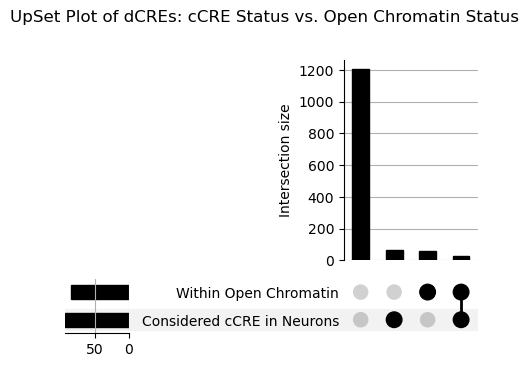

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import plot, from_indicators # Changed from_memberships to from_indicators
from upsetplot import plot, from_memberships # Import plot and from_memberships for UpSet plots
import matplotlib.colors as mcolors
import matplotlib.cm as cm


df_initial_set = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True].copy()

# --- Prepare data for UpSet Plot using from_indicators ---
# 1. Select the boolean indicator columns and the 'count' column.
df_for_upset_prep = df_initial_set[[
    'is_npc_or_excitatory_SCREEN_cre',
    'is_open_NGN2_WTC11_ATAC_1_3_overlap',
    'count'
]].copy()

# 2. Rename columns for clearer labels in the plot.
df_for_upset_prep.rename(columns={
    'is_npc_or_excitatory_SCREEN_cre': 'Considered cCRE in Neurons',
    'is_open_NGN2_WTC11_ATAC_1_3_overlap': 'Within Open Chromatin'
}, inplace=True)

# 3. Use from_indicators to create the Series with a MultiIndex.
# The first argument is the DataFrame of boolean indicators (all columns except 'count').
# The 'data' argument is the Series of counts.
upset_data = from_indicators(
    df_for_upset_prep.iloc[:, :-1], # All columns except the last one ('count') are indicators
    data=df_for_upset_prep['count'] # The 'count' column provides the size for each combination
)

# --- Create the UpSet Plot ---
fig = plt.figure(figsize=(10, 7))
# Pass the MultiIndex Series directly to plot()
plot(upset_data, fig=fig)

# Add a title to the plot
plt.suptitle('UpSet Plot of dCREs: cCRE Status vs. Open Chromatin Status', y=1.02)

plt.show()

### Add the increasing and decreasing dCREs in NGN2 neurons

In [ ]:
df_elements_no_alternative_count = df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_increasing_dCRE_NGN2", "is_decreasing_dCRE_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')
df_elements_no_alternative_count

In [ ]:
# import pandas as pd
# import plotly.graph_objects as go
# # --- 2. Define Node Labels and Colors ---
# # A list of all unique node labels that will appear in the diagram.
# # The order here defines their index for source/target
# node_labels = [
#     "All Sequences",                                    # 0
#     "Significant regulatory sequences",                 # 1
#     "no significant regulatory activity",               # 2 (end node)
#     "enhancing sequences",                              # 3 (NEW)
#     "silencing sequences",                              # 4 (NEW)
#     "SCREEN: True (enhancing)",                         # 5 (from enhancing)
#     "SCREEN: False (enhancing)",                        # 6 (from enhancing)
#     "SCREEN: True (silencing)",                         # 7 (from silencing)
#     "SCREEN: False (silencing)",                        # 8 (from silencing)
#     "Open Chromatin: True (enhancing-branch)",          # 9 (from enhancing->SCREEN:False)
#     "Open Chromatin: False (enhancing-branch)",         # 10 (from enhancing->SCREEN:False)
#     "Open Chromatin: True (silencing-branch)",          # 11 (from silencing->SCREEN:False)
#     "Open Chromatin: False (silencing-branch)"          # 12 (from silencing->SCREEN:False)
# ]

# # Assigning unique indices to each node label
# label_to_index = {label: i for i, label in enumerate(node_labels)}

# # You can define colors for your nodes and links for better visualization
# node_colors = [
#     'lightgray',          # All Sequences
#     '#AEC6CF',            # Significant regulatory sequences (Light Blue)
#     '#FFADAD',            # no significant regulatory activity (Light Red)
#     '#90EE90',            # enhancing sequences (Light Green)
#     '#FFC0CB',            # silencing sequences (Pink)
#     '#87CEEB',            # SCREEN: True (enhancing) (Sky Blue)
#     '#ADD8E6',            # SCREEN: False (enhancing) (Light Blue)
#     '#6495ED',            # SCREEN: True (silencing) (Cornflower Blue)
#     '#B0C4DE',            # SCREEN: False (silencing) (Light Steel Blue)
#     '#32CD32',            # Open Chromatin: True (enhancing-branch) (Lime Green)
#     '#FFA07A',            # Open Chromatin: False (enhancing-branch) (Light Salmon)
#     '#228B22',            # Open Chromatin: True (silencing-branch) (Forest Green)
#     '#FF8C00'             # Open Chromatin: False (silencing-branch) (Dark Orange)
# ]

# # --- 3. Prepare Source, Target, and Value Lists for Sankey ---
# sources = []
# targets = []
# values = []
# link_colors = [] # Will be populated based on source/target node colors

# # --- Step 1: All Sequences -> is_dCRE_NGN2 (True/False) ---
# total_sequences = df_elements_no_alternative_count['count'].sum()

# # Flow to "Significant regulatory sequences"
# sig_true_count = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True]['count'].sum()
# sources.append(label_to_index["All Sequences"])
# targets.append(label_to_index["Significant regulatory sequences"])
# values.append(sig_true_count)
# link_colors.append(node_colors[label_to_index["Significant regulatory sequences"]])

# # Flow to "no significant regulatory activity"
# sig_false_count = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == False]['count'].sum()
# sources.append(label_to_index["All Sequences"])
# targets.append(label_to_index["no significant regulatory activity"])
# values.append(sig_false_count)
# link_colors.append(node_colors[label_to_index["no significant regulatory activity"]])

# # --- Step 1.5: Significant regulatory sequences -> enhancing/silencing sequences ---
# df_sig_true = df_elements_no_alternative_count[df_elements_no_alternative_count["is_dCRE_NGN2"] == True]

# # Sig True -> enhancing sequences
# enhancing_count = df_sig_true[df_sig_true["is_increasing_dCRE_NGN2"] == True]['count'].sum()
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["enhancing sequences"])
# values.append(enhancing_count)
# link_colors.append(node_colors[label_to_index["enhancing sequences"]])

# # Sig True -> silencing sequences
# silencing_count = df_sig_true[df_sig_true["is_decreasing_dCRE_NGN2"] == True]['count'].sum()
# sources.append(label_to_index["Significant regulatory sequences"])
# targets.append(label_to_index["silencing sequences"])
# values.append(silencing_count)
# link_colors.append(node_colors[label_to_index["silencing sequences"]])


# # --- Step 2: Branching for enhancing sequences -> SCREEN ---
# df_enhancing = df_sig_true[df_sig_true["is_increasing_dCRE_NGN2"] == True]

# if not df_enhancing.empty:
#     # enhancing -> SCREEN True
#     sources.append(label_to_index["enhancing sequences"])
#     targets.append(label_to_index["SCREEN: True (enhancing)"])
#     values.append(df_enhancing[df_enhancing["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["SCREEN: True (enhancing)"]])

#     # enhancing -> SCREEN False
#     sources.append(label_to_index["enhancing sequences"])
#     targets.append(label_to_index["SCREEN: False (enhancing)"])
#     values.append(df_enhancing[df_enhancing["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["SCREEN: False (enhancing)"]])


# # --- Step 2: Branching for silencing sequences -> SCREEN ---
# df_silencing = df_sig_true[df_sig_true["is_decreasing_dCRE_NGN2"] == True]

# if not df_silencing.empty:
#     # silencing -> SCREEN True
#     sources.append(label_to_index["silencing sequences"])
#     targets.append(label_to_index["SCREEN: True (silencing)"])
#     values.append(df_silencing[df_silencing["is_npc_or_excitatory_SCREEN_cre"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["SCREEN: True (silencing)"]])

#     # silencing -> SCREEN False
#     sources.append(label_to_index["silencing sequences"])
#     targets.append(label_to_index["SCREEN: False (silencing)"])
#     values.append(df_silencing[df_silencing["is_npc_or_excitatory_SCREEN_cre"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["SCREEN: False (silencing)"]])


# # --- Step 3: Branching for (SCREEN: False, enhancing) -> Open Chromatin ---
# df_enhancing_screen_false = df_enhancing[df_enhancing["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_enhancing_screen_false.empty:
#     sources.append(label_to_index["SCREEN: False (enhancing)"])
#     targets.append(label_to_index["Open Chromatin: True (enhancing-branch)"])
#     values.append(df_enhancing_screen_false[df_enhancing_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: True (enhancing-branch)"]])

#     sources.append(label_to_index["SCREEN: False (enhancing)"])
#     targets.append(label_to_index["Open Chromatin: False (enhancing-branch)"])
#     values.append(df_enhancing_screen_false[df_enhancing_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: False (enhancing-branch)"]])
# else:
#     print("No sequences found for 'enhancing' AND 'SCREEN: False'. The enhancing-branch Open Chromatin branch won't appear.")


# # --- Step 3: Branching for (SCREEN: False, silencing) -> Open Chromatin ---
# df_silencing_screen_false = df_silencing[df_silencing["is_npc_or_excitatory_SCREEN_cre"] == False]

# if not df_silencing_screen_false.empty:
#     sources.append(label_to_index["SCREEN: False (silencing)"])
#     targets.append(label_to_index["Open Chromatin: True (silencing-branch)"])
#     values.append(df_silencing_screen_false[df_silencing_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == True]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: True (silencing-branch)"]])

#     sources.append(label_to_index["SCREEN: False (silencing)"])
#     targets.append(label_to_index["Open Chromatin: False (silencing-branch)"])
#     values.append(df_silencing_screen_false[df_silencing_screen_false["is_open_NGN2_WTC11_ATAC_1_3_overlap"] == False]['count'].sum())
#     link_colors.append(node_colors[label_to_index["Open Chromatin: False (silencing-branch)"]])
# else:
#     print("No sequences found for 'silencing' AND 'SCREEN: False'. The silencing-branch Open Chromatin branch won't appear.")


# # --- 4. Create the Sankey Plot ---
# fig = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=node_labels,
#         color=node_colors
#     ),
#     link=dict(
#         source=sources,
#         target=targets,
#         value=values,
#         color=link_colors # Using link_colors to match target node color often looks good
#     )
# )])

# fig.update_layout(
#     title_text="Flow of Sequences through Annotation Criteria (Enhanced with Enhancing/Silencing Split)",
#     font_size=10, # Adjusted for more labels
#     height=700, # Adjusted height for more nodes
#     width=1100,  # Adjusted width for more nodes
# )

# fig.show()

### Todo: get the biosample of the screen ids which are active but are not overlapping any open-chromatin and other screen marks in neuron cells

In [ ]:
df_elements_no_alternative.groupby(["is_dCRE_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]).size().reset_index(name='count')

In [ ]:
df_elements_no_alternative

In [ ]:
columns_of_interest = ["is_dCRE_NGN2", "is_npc_or_excitatory_SCREEN_cre", "is_open_NGN2_WTC11_ATAC_1_3_overlap"]
df_elements_no_alternatives_active_no_screen_not_open = df_elements_no_alternative.loc[df_elements_no_alternative["is_dCRE_NGN2"] & (~df_elements_no_alternative["is_npc_or_excitatory_SCREEN_cre"]) & (~df_elements_no_alternative["is_open_NGN2_WTC11_ATAC_1_3_overlap"])].copy()
df_elements_no_alternatives_active_no_screen_not_open["SCREEN_ID"].nunique()

In [ ]:
df_elements_no_alternatives_active_no_screen_not_open["SCREEN_ID"].to_list()[:4]

#### Get for a SCREEN id all the biosample-specific epigenetic signals 
https://github.com/weng-lab/SCREEN2.0/blob/main/screen2.0/src/app/search/_ccredetails/queries.ts

##### minimal example (working)

In [ ]:
import requests
variables = {
  "accession": ['EH38E1825144'],
  "assembly": "grch38"
}
# variables = {
#   "accession": ['EH38E3006823', 'EH38E1825144'],
#   "assembly": "grch38"
# }
query = """
query cCREQuery($accession: [String!], $assembly: String!) {
  cCREQuery(accession: $accession, assembly: $assembly) {
    coordinates {
        start
        end
        chromosome
      }
      rDHS
      assembly
    }
}
"""
# query = """
# query {
#    ccREBiosampleQuery(assembly: "grch38", $accession: [String!]) {
#     biosamples {
#       sampleType
#       cCREZScores(accession: $accession) {
#         score
#         assay
#         experiment_accession
#       }
#       name
#       ontology
#     }
#   }
# }
# """

query = """
  query topTissues($accession: [String!], $assembly: String!) {
    ccREBiosampleQuery(assembly: $assembly) {
      biosamples {
        sampleType
        displayname
        cCREZScores(accession: $accession) {
          score
          assay
          experiment_accession
        }
        name
        ontology
      }
    }
    cCREQuery(assembly: $assembly, accession: $accession) {
      accession
      group
      dnase: maxZ(assay: "DNase")
      h3k4me3: maxZ(assay: "H3K4me3")
      h3k27ac: maxZ(assay: "H3K27ac")
      ctcf: maxZ(assay: "CTCF")
      atac: maxZ(assay: "ATAC")
    }
  }
"""

request = requests.post(
    'https://factorbook.api.wenglab.org/graphql',
    json={ 'query': query, 'variables': variables },
    headers={}
)
if request.status_code != 200:
    raise Exception("Query failed. Status code: {}.".format(request.status_code))
result = request.json()
print(result)

In [ ]:
result['data'].keys()
result['data']['ccREBiosampleQuery'].keys()
# result['data']['ccREBiosampleQuery']['biosamples']
result['data']['cCREQuery']

In [ ]:
# [{'accession': 'EH38E1825144',
#   'group': 'pELS',
#   'dnase': 3.1959331035614014,
#   'h3k4me3': 1.485369086265564,
#   'h3k27ac': 1.887129306793213,
#   'ctcf': 1.6286468505859375,
#   'atac': 1.5468889474868774},
#  {'accession': 'EH38E3006823',
#   'group': 'dELS',
#   'dnase': 2.129223585128784,
#   'h3k4me3': 1.6235357522964478,
#   'h3k27ac': 2.689836025238037,
#   'ctcf': 1.5138598680496216,
#   'atac': 2.5685484409332275}]

In [ ]:
type(result['data']['ccREBiosampleQuery']['biosamples'])
len(result['data']['ccREBiosampleQuery']['biosamples'])
result['data']['ccREBiosampleQuery']['biosamples'][0]

In [ ]:
result['data']['ccREBiosampleQuery']['biosamples'][87].keys()

In [ ]:
result['data']['ccREBiosampleQuery']['biosamples'][87]

In [ ]:
len(result['data']['ccREBiosampleQuery']['biosamples']) # 1888
example_result = result['data']['ccREBiosampleQuery']['biosamples'][87]
example_result
# do all the keys of these dicts are the same?
a = ['sampleType', 'displayname', 'cCREZScores', 'name', 'ontology']
counter = 0
for elem in result['data']['ccREBiosampleQuery']['biosamples']:
    if a != list(elem.keys()):
        print(elem)
        break
    counter += 1
print(counter)

In [ ]:
list(example_result.keys())

In [ ]:
a = ['sampleType', 'displayname', 'cCREZScores', 'name', 'ontology']

b = list(example_result.keys())

a == b

In [ ]:
examples:

new results:
    {'sampleType': 'cell line',
 'displayname': 'A172',
 'cCREZScores': [{'score': 0.6154453158378601,
   'assay': 'dnase',
   'experiment_accession': 'ENCSR932KWJ'}],
 'name': 'A172_ENCDO934VEN',
 'ontology': 'brain'}


first:
{'sampleType': 'in vitro differentiated cells',
'cCREZScores': [{'score': 2.049172878265381,
'assay': 'dnase',
'experiment_accession': 'ENCSR405TXU'}],
'name': 'adipocyte_ENCDO029QEV',
'ontology': 'connective tissue'}

{'sampleType': 'cell line',
 'cCREZScores': [{'score': 1.6989964246749878,
   'assay': 'dnase',
   'experiment_accession': 'ENCSR000EID'}],
 'name': '8988T_ENCDO000ACP',
 'ontology': 'pancreas'}


{'sampleType': 'cell line',
 'cCREZScores': [{'score': 3.923966646194458,
   'assay': 'ctcf',
   'experiment_accession': 'ENCSR857PBV'},
  {'score': -0.07481276988983154,
   'assay': 'h3k27ac',
   'experiment_accession': 'ENCSR391NPE'}],
 'name': '22Rv1_ENCDO719HIY',
 'ontology': 'prostate'}


{'sampleType': 'cell line',
 'cCREZScores': [{'score': 1.9272712469100952,
   'assay': 'dnase',
   'experiment_accession': 'ENCSR932KWJ'}],
 'name': 'A172_ENCDO934VEN',
 'ontology': 'brain'}

In [ ]:
import pandas as pd
import requests
import json
from tqdm import tqdm

# --- 1. Your SCREEN IDs (EH38E) ---
data = {
    'SCREEN_ID': [
        'EH38E1825144'
    ]
}
df_elements = pd.DataFrame(data)
eh_screen_ids = df_elements["SCREEN_ID"].tolist()
print(f"Number of EH38E IDs to query: {len(eh_screen_ids)}")


# --- 2. Define the GraphQL API Endpoint ---
FACTORBOOK_API_URL = "https://factorbook.api.wenglab.org/graphql"

# --- 3. Helper function to execute GraphQL queries ---
def run_graphql_query(url, query, variables=None):
    """
    Executes a GraphQL query against a specified URL.
    Handles JSON payload and error checking.
    """
    # --- THE CHANGE IS HERE: Use 'json' parameter directly and an empty 'headers' dict ---
    payload = {"query": query}
    if variables:
        payload["variables"] = variables

    response = requests.post(url, json=payload, headers={}) # Matching user's working example
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return response.json()

# --- 4. Define the combined GraphQL query ---
combined_query = """
query topTissues($accession: [String!], $assembly: String!) {
  ccREBiosampleQuery(assembly: $assembly) {
    biosamples {
      sampleType
      displayname
      cCREZScores(accession: $accession) {
        score
        assay
        experiment_accession
      }
      name
      ontology
    }
  }
  cCREQuery(assembly: $assembly, accession: $accessions) { # Changed $accession to $accessions in cCREQuery based on schema common practice
    accession
    group
    dnase: maxZ(assay: "DNase")
    h3k4me3: maxZ(assay: "H3K4me3")
    h3k27ac: maxZ(assay: "H3K27ac")
    ctcf: maxZ(assay: "CTCF")
    atac: maxZ(assay: "ATAC")
  }
}
"""

# --- Self-correction in thought: I made a typo in the GraphQL query above.
# It should be 'accession: $accession' not 'accession: $accessions'
# in the cCREQuery. The user's original query used '$accession'.
# I need to revert that specific change. ---

# Corrected combined_query:
combined_query = """
query topTissues($accession: [String!], $assembly: String!) {
  ccREBiosampleQuery(assembly: $assembly) {
    biosamples {
      sampleType
      displayname
      cCREZScores(accession: $accession) {
        score
        assay
        experiment_accession
      }
      name
      ontology
    }
  }
  cCREQuery(assembly: $assembly, accession: $accession) { # Corrected back to $accession
    accession
    group
    dnase: maxZ(assay: "DNase")
    h3k4me3: maxZ(assay: "H3K4me3")
    h3k27ac: maxZ(assay: "H3K27ac")
    ctcf: maxZ(assay: "CTCF")
    atac: maxZ(assay: "ATAC")
  }
}
"""


# --- 5. Prepare base variables for the query ---
base_query_variables = {
    "assembly": "grch38"
}

print("\n--- Executing combined query against Factorbook API ---")

# --- 6. Execute the combined query with BATCH_SIZE = 1 for isolation ---
BATCH_SIZE = 1

all_biosample_data = []
all_ccre_group_data = []

for i in tqdm(range(0, len(eh_screen_ids), BATCH_SIZE), desc="Querying Factorbook"):
    batch_ids = eh_screen_ids[i:i + BATCH_SIZE]
    query_variables = base_query_variables.copy()
    query_variables["accession"] = batch_ids

    try:
        response_data = run_graphql_query(FACTORBOOK_API_URL, combined_query, query_variables)

        # Process cCREQuery results
        if "data" in response_data and response_data["data"].get("cCREQuery"):
            for ccre_info in response_data["data"]["cCREQuery"]:
                all_ccre_group_data.append({
                    'SCREEN_ID': ccre_info.get('accession'),
                    'group': ccre_info.get('group'),
                    'dnase_maxZ': ccre_info.get('dnase'),
                    'h3k4me3_maxZ': ccre_info.get('h3k4me3'),
                    'h3k27ac_maxZ': ccre_info.get('h3k27ac'),
                    'ctcf_maxZ': ccre_info.get('ctcf'),
                    'atac_maxZ': ccre_info.get('atac')
                })
        else:
            for s_id in batch_ids:
                if not any(d.get('SCREEN_ID') == s_id for d in all_ccre_group_data):
                    all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': 'No cCREQuery data'})


        # Process ccREBiosampleQuery results
        if "data" in response_data and response_data["data"].get("ccREBiosampleQuery"):
            for biosample_entry in response_data["data"]["ccREBiosampleQuery"].get("biosamples", []):
                biosample_name = biosample_entry.get('name')
                biosample_displayname = biosample_entry.get('displayname')
                biosample_ontology = biosample_entry.get('ontology')
                sample_type = biosample_entry.get('sampleType')

                if biosample_entry.get('cCREZScores'):
                    for zscore_entry in biosample_entry['cCREZScores']:
                        all_biosample_data.append({
                            'SCREEN_ID': zscore_entry.get('accession'),
                            'biosample_name': biosample_name,
                            'biosample_displayname': biosample_displayname,
                            'biosample_ontology': biosample_ontology,
                            'sample_type': sample_type,
                            'z_score': zscore_entry.get('score'),
                            'assay': zscore_entry.get('assay'),
                            'experiment_accession': zscore_entry.get('experiment_accession')
                        })
        else:
            for s_id in batch_ids:
                if not any(d.get('SCREEN_ID') == s_id for d in all_biosample_data):
                     all_biosample_data.append({'SCREEN_ID': s_id, 'biosample_name': None, 'error': 'No Biosample Z-score data'})

        if "errors" in response_data:
            print(f"\nGraphQL Errors for batch {batch_ids}: {response_data['errors']}")
            for s_id in batch_ids:
                if not any(d.get('SCREEN_ID') == s_id and 'error' in d for d in all_ccre_group_data):
                    all_ccre_group_data.append({'SCREEN_ID': s_id, 'error': 'GraphQL Error'})
                if not any(d.get('SCREEN_ID') == s_id and 'error' in d for d in all_biosample_data):
                    all_biosample_data.append({'SCREEN_ID': s_id, 'error': 'GraphQL Error'})

    except requests.exceptions.RequestException as e:
        print(f"\nNetwork error for batch {batch_ids}: {e}")
        for s_id in batch_ids:
            all_ccre_group_data.append({'SCREEN_ID': s_id, 'error': 'Network Error'})
            all_biosample_data.append({'SCREEN_ID': s_id, 'error': 'Network Error'})
    except Exception as e:
        print(f"\nAn unexpected error occurred for batch {batch_ids}: {e}")
        for s_id in batch_ids:
            all_ccre_group_data.append({'SCREEN_ID': s_id, 'error': 'Unexpected Error'})
            all_biosample_data.append({'SCREEN_ID': s_id, 'error': 'Unexpected Error'})


df_ccre_groups = pd.DataFrame(all_ccre_group_data)
df_biosample_zscores = pd.DataFrame(all_biosample_data)

print("\n--- Raw cCRE Group Data (first 5 rows) ---")
print(df_ccre_groups.head())
print(f"Shape: {df_ccre_groups.shape}")

print("\n--- Raw Biosample Z-Scores Data (first 5 rows) ---")
print(df_biosample_zscores.head())
print(f"Shape: {df_biosample_zscores.shape}")


# --- 7. Process and Merge Data ---

# Merge cCRE group information with biosample Z-scores
merged_df = pd.merge(df_biosample_zscores, df_ccre_groups, on='SCREEN_ID', how='left')

# Define target groups for filtering
target_groups = ["dELS", "pELS", "PLS"]

# Filter the merged DataFrame to include only cCREs in the target groups
filtered_by_group_df = merged_df[merged_df['group'].isin(target_groups)].copy()

# Identify active biosamples based on a Z-score threshold
ZSCORE_THRESHOLD = 1.64
active_biosamples_df = filtered_by_group_df[filtered_by_group_df['z_score'].notna()]
active_biosamples_df = active_biosamples_df[active_biosamples_df['z_score'] >= ZSCORE_THRESHOLD]

# Group by original SCREEN_ID and collect unique active biosample display names
active_biosamples_per_ccre = active_biosamples_df.groupby('SCREEN_ID')['biosample_displayname'].apply(
    lambda x: list(x.dropna().unique())
).reset_index(name='Active_Biosamples_in_Target_Group')

# Create a final summary DataFrame for each original SCREEN_ID
final_summary_df = df_elements.copy()

# Add the cCRE group information to the summary
final_summary_df = pd.merge(final_summary_df, df_ccre_groups[['SCREEN_ID', 'group']].drop_duplicates(), on='SCREEN_ID', how='left')

# Add the active biosamples list
final_summary_df = pd.merge(final_summary_df, active_biosamples_per_ccre, on='SCREEN_ID', how='left')

# Fill NaN values for 'group' and 'Active_Biosamples_in_Target_Group'
final_summary_df['group'].fillna('Not Found or Error', inplace=True)
final_summary_df['Active_Biosamples_in_Target_Group'].fillna(value='No Active Biosamples in Target Groups', inplace=True)

print("\n--- Final Summary: EH38E IDs with their Group and Associated Active Biosamples ---")
print(final_summary_df)

Check here the AI supported query:

In [ ]:
df_biosample_zscores

In [ ]:
# merged_df

In [ ]:
# final_summary_df

In [ ]:
type(response_data["data"].get('cCREZScores'))
response_data["data"].get('cCREZScores')

In [ ]:
response_data['data'].keys()
response_data['data'].get('cCREQuery')

In [ ]:
for biosample_entry in response_data["data"]["ccREBiosampleQuery"].get("biosamples", []):
    if biosample_entry.get('cCREZScores'):
        for zscore_entry in biosample_entry.get('cCREZScores'):
            print("Hallo")
            print(zscore_entry)
            print(type(zscore_entry))
            break
        break


In [ ]:
zscore_entry.get('accession')

##### Working example which returns a big table with group and biosample list for each SCREEN_ID

In [ ]:
import pandas as pd
import requests
import json
from tqdm import tqdm

# --- 1. Your SCREEN IDs (EH38E) ---
data = {
    'SCREEN_ID': ['EH38E1825144', 'EH38E3006823', 'EH38E3127094', 'EH38E3127097']
}
df_elements = pd.DataFrame(data)
eh_screen_ids = df_elements["SCREEN_ID"].tolist()
eh_screen_ids = list(df_elements_no_alternatives_active_no_screen_not_open["SCREEN_ID"].unique())
print(f"Number of EH38E IDs to query: {len(eh_screen_ids)}")

# --- 2. Define the GraphQL API Endpoint ---
FACTORBOOK_API_URL = "https://factorbook.api.wenglab.org/graphql"

# --- 3. Helper function to execute GraphQL queries ---
def run_graphql_query(url, query, variables=None):
    """
    Executes a GraphQL query against a specified URL.
    Handles JSON payload and error checking.
    """
    # Using 'json' parameter directly and an empty 'headers' dict as per user's working example
    payload = {"query": query}
    if variables:
        payload["variables"] = variables

    response = requests.post(url, json=payload, headers={}) # Matching user's working example
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return response.json()

# --- 4. Define the combined GraphQL query ---
# This query fetches both biosample Z-scores (via ccREBiosampleQuery)
# and cCRE group/maxZ scores (via cCREQuery) from the Factorbook API.
# It uses variables for accession (list of IDs) and assembly.
combined_query = """
query topTissues($accession: [String!], $assembly: String!) {
  ccREBiosampleQuery(assembly: $assembly) {
    biosamples {
      sampleType
      displayname
      cCREZScores(accession: $accession) {
        score
        assay
        experiment_accession
      }
      name
      ontology
    }
  }
  cCREQuery(assembly: $assembly, accession: $accession) {
    accession # This accession reflects the input accession for this specific cCRE
    group
    dnase: maxZ(assay: "DNase")
    h3k4me3: maxZ(assay: "H3K4me3")
    h3k27ac: maxZ(assay: "H3K27ac")
    ctcf: maxZ(assay: "CTCF")
    atac: maxZ(assay: "ATAC")
  }
}
"""
combined_query = """
  query topTissues($accession: [String!], $assembly: String!) {
    ccREBiosampleQuery(assembly: $assembly) {
      biosamples {
        sampleType
        displayname
        cCREZScores(accession: $accession) {
          score
          assay
          experiment_accession
        }
        name
        ontology
      }
    }
    cCREQuery(assembly: $assembly, accession: $accession) {
      accession
      group
      dnase: maxZ(assay: "DNase")
      h3k4me3: maxZ(assay: "H3K4me3")
      h3k27ac: maxZ(assay: "H3K27ac")
      ctcf: maxZ(assay: "CTCF")
      atac: maxZ(assay: "ATAC")
    }
  }
"""

# --- 5. Prepare base variables for the query ---
base_query_variables = {
    "assembly": "grch38" # Assuming GRCh38 as per your examples
}

print("\n--- Executing combined query against Factorbook API ---")

# --- 6. Execute the combined query with BATCH_SIZE = 1 for isolation ---
# This ensures we query one SCREEN_ID at a time as suggested by the user.
BATCH_SIZE = 1

all_biosample_data = [] # To store detailed biosample Z-scores
all_ccre_group_data = [] # To store cCRE group and maxZ scores

for i in tqdm(range(0, len(eh_screen_ids), BATCH_SIZE), desc="Querying Factorbook"):
    batch_ids = eh_screen_ids[i:i + BATCH_SIZE]
    s_id = batch_ids[0] # Get the single SCREEN_ID for this iteration

    query_variables = base_query_variables.copy()
    query_variables["accession"] = batch_ids # Pass the single ID as a list

    try:
        response_data = run_graphql_query(FACTORBOOK_API_URL, combined_query, query_variables)

        # Process cCREQuery results (group and maxZ scores)
        # We explicitly associate the result with the current s_id
        if "data" in response_data and response_data["data"].get("cCREQuery"):
            found_ccre_info = False
            for ccre_info in response_data["data"]["cCREQuery"]:
                if isinstance(ccre_info, dict) and ccre_info.get('accession') == s_id: # Ensure it's the data for our current s_id
                    all_ccre_group_data.append({
                        'SCREEN_ID': s_id, # Use the input s_id for mapping
                        'group': ccre_info.get('group'),
                        'dnase_maxZ': ccre_info.get('dnase'),
                        'h3k4me3_maxZ': ccre_info.get('h3k4me3'),
                        'h3k27ac_maxZ': ccre_info.get('h3k27ac'),
                        'ctcf_maxZ': ccre_info.get('ctcf'),
                        'atac_maxZ': ccre_info.get('atac')
                    })
                    found_ccre_info = True
                    break # Found the relevant cCRE info for this s_id

            if not found_ccre_info: # If cCREQuery data section was there, but no info for this s_id
                 all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': f'No matching cCREQuery data found for {s_id}'})
        else: # If "data" or "cCREQuery" is missing/empty in response_data
            all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': f'No cCREQuery section in response for {s_id}'})

        print("print response data", response_data)
        # Process ccREBiosampleQuery results (biosamples and Z-scores)
        # Explicitly associate with the current s_id
        biosample_data_for_s_id_found = False
        if "data" in response_data and response_data["data"].get("ccREBiosampleQuery"):
            for biosample_entry in response_data["data"]["ccREBiosampleQuery"].get("biosamples", []):
                if biosample_entry.get('cCREZScores'):
                    for zscore_entry in biosample_entry.get('cCREZScores'):
                        if isinstance(zscore_entry, dict): # Ensure score is for current s_id
                            all_biosample_data.append({
                                'SCREEN_ID': s_id, # Use the input s_id for mapping
                                'biosample_name': biosample_entry.get('name'),
                                'biosample_displayname': biosample_entry.get('displayname'),
                                'biosample_ontology': biosample_entry.get('ontology'),
                                'sample_type': biosample_entry.get('sampleType'),
                                'z_score': zscore_entry.get('score'),
                                'assay': zscore_entry.get('assay'),
                                'experiment_accession': zscore_entry.get('experiment_accession')
                            })
                            biosample_data_for_s_id_found = True

        if not biosample_data_for_s_id_found: # If biosample data section was there, but no scores for this s_id
            all_biosample_data.append({'SCREEN_ID': s_id, 'biosample_name': None, 'error': f'No valid Biosample Z-score data for {s_id}'})


        if "errors" in response_data: # Capture top-level GraphQL errors
            error_messages = [err.get('message', 'Unknown error') for err in response_data['errors']]
            print(f"\nGraphQL Errors for SCREEN_ID {s_id}: {error_messages}")
            # Add error entry if not already added by specific data processing
            if not any(d.get('SCREEN_ID') == s_id and 'error' in d for d in all_ccre_group_data):
                all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': f'GraphQL Error: {error_messages}'})
            if not any(d.get('SCREEN_ID') == s_id and 'error' in d for d in all_biosample_data):
                all_biosample_data.append({'SCREEN_ID': s_id, 'biosample_name': None, 'error': f'GraphQL Error: {error_messages}'})


    except requests.exceptions.RequestException as e:
        # This catches HTTP errors like 400, 404, etc.
        print(f"\nNetwork error for SCREEN_ID {s_id}: {e}")
        all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': f'Network Error: {e}'})
        all_biosample_data.append({'SCREEN_ID': s_id, 'biosample_name': None, 'error': f'Network Error: {e}'})
    except Exception as e:
        # Catch any other unexpected Python errors during processing
        print(f"\nAn unexpected error occurred for SCREEN_ID {s_id}: {e}")
        all_ccre_group_data.append({'SCREEN_ID': s_id, 'group': None, 'error': f'Unexpected Error: {e}'})
        all_biosample_data.append({'SCREEN_ID': s_id, 'biosample_name': None, 'error': f'Unexpected Error: {e}'})


df_ccre_groups = pd.DataFrame(all_ccre_group_data)
df_biosample_zscores = pd.DataFrame(all_biosample_data)

print("\n--- Raw cCRE Group Data (first 5 rows) ---")
print(df_ccre_groups.head())
print(f"Shape: {df_ccre_groups.shape}")

print("\n--- Raw Biosample Z-Scores Data (first 5 rows) ---")
print(df_biosample_zscores.head())
print(f"Shape: {df_biosample_zscores.shape}")


# --- 7. Process and Merge Data ---

# Merge cCRE group information with biosample Z-scores
# Note: A single SCREEN_ID might have multiple biosample Z-scores, so this merge will expand rows.
merged_df = pd.merge(df_biosample_zscores, df_ccre_groups, on='SCREEN_ID', how='left')

# Define target groups for filtering
target_groups = ["dELS", "pELS", "PLS"]

# Filter the merged DataFrame to include only cCREs in the target groups
# Ensure 'group' column exists and is not None before filtering
# Use .dropna() on 'group' to ensure no None values if they slipped through
filtered_by_group_df = merged_df[merged_df['group'].isin(target_groups)].copy()

# Identify active biosamples based on a Z-score threshold (e.g., >= 1.64 for ~95th percentile)
ZSCORE_THRESHOLD = 1.64
active_biosamples_df = filtered_by_group_df[filtered_by_group_df['z_score'].notna()]
active_biosamples_df = active_biosamples_df[active_biosamples_df['z_score'] >= ZSCORE_THRESHOLD]

# Group by original SCREEN_ID and collect unique active biosample display names
# This aggregates the biosample information back to one row per cCRE,
# listing all active biosamples for that cCRE within the target groups.
active_biosamples_per_ccre = active_biosamples_df.groupby('SCREEN_ID')['biosample_displayname'].apply(
    lambda x: list(x.dropna().unique())
).reset_index(name='Active_Biosamples_in_Target_Group')

# Create a final summary DataFrame for each original SCREEN_ID
final_summary_df = df_elements.copy() # Start with all original SCREEN_IDs

# Add the cCRE group information to the summary (deduplicated as it's one group per ID)
final_summary_df = pd.merge(final_summary_df, df_ccre_groups[['SCREEN_ID', 'group']].drop_duplicates(), on='SCREEN_ID', how='left')

# Add the active biosamples list
final_summary_df = pd.merge(final_summary_df, active_biosamples_per_ccre, on='SCREEN_ID', how='left')

# Fill NaN values for 'group' and 'Active_Biosamples_in_Target_Group' if no data was found or
# if the cCRE was not in the target groups / had no active biosamples.
# Check if 'group' column exists before trying to fillna, if it might not exist at all
if 'group' not in final_summary_df.columns:
    final_summary_df['group'] = None # Add it if missing
final_summary_df['group'].fillna('Not Found or Error', inplace=True)

if 'Active_Biosamples_in_Target_Group' not in final_summary_df.columns:
    final_summary_df['Active_Biosamples_in_Target_Group'] = None # Add it if missing
final_summary_df['Active_Biosamples_in_Target_Group'].fillna(value='No Active Biosamples in Target Groups', inplace=True)

print("\n--- Final Summary: EH38E IDs with their Group and Associated Active Biosamples ---")
print(final_summary_df)

In [ ]:
final_summary_df

In [ ]:
writing = False
if writing:
    final_summary_df.to_csv("./screen_summary_of_SCREEN_ids_without_marks_in_Neurons.csv", sep="\t", index=None)

In [ ]:
final_summary_df['Active_Biosamples_in_Target_Group'].to_list()

In [ ]:
response_data["data"].get("ccREBiosampleQuery")
response_data["data"].get("ccREBiosampleQuery").keys()
response_data["data"].get("ccREBiosampleQuery").get('biosamples')
response_data["data"].get("cCREQuery")
# if response_data["data"].get("ccREBiosampleQuery").get('cCREZScores'):
#     print("Hallo")

In [ ]:
response_data["data"].get("ccREBiosampleQuery").get('biosample_entry')

In [ ]:
df_biosample_zscores

In [ ]:
df_ccre_groups

old: (not working)

In [ ]:
import pandas as pd
import requests
import json
from tqdm import tqdm

# --- 1. Your SCREEN IDs (EH38E) ---
data = {
    'SCREEN_ID': [
        'EH38E1825144', 'EH38E3006823', 'EH38E3127094', 'EH38E3127097',
        'EH38E2941922',
        'EH38E3000000', # Non-existent example
        'EH38E1516972' # Your new example
    ]
}
df_elements = pd.DataFrame(data)
eh_screen_ids = df_elements["SCREEN_ID"].tolist()
print(f"Number of EH38E IDs to query: {len(eh_screen_ids)}")

# --- 2. Define API Endpoints ---
FACTORBOOK_API_URL = "https://factorbook.api.wenglab.org/graphql"
SCREEN_API_URL = "https://screen.encodeproject.org/graphql"

# --- 3. Helper function to execute GraphQL queries ---
def run_graphql_query(url, query, variables=None):
    headers = {"Content-Type": "application/json"}
    payload = {"query": query}
    if variables:
        payload["variables"] = variables

    # Using 'json' parameter for requests.post for simplicity, as your example showed it works for Factorbook.
    # If errors persist, we can switch to `data=json.dumps(payload)`
    response = requests.post(url, headers=headers, json=payload)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return response.json()

# --- STEP 1: Query Factorbook API for Coordinates of EH38E IDs ---
print("\n--- Step 1: Fetching coordinates from Factorbook API for EH38E IDs ---")
eh_id_coordinates = {}

query_factorbook_coordinates = """
query cCREQuery($assembly: String!, $accession: [String!]) {
  cCREQuery(accession: $accession, assembly: $assembly) {
    accession
    coordinates {
        start
        end
        chromosome
      }
      rDHS
      assembly
    }
}
"""

query = """
query {
   ccREBiosampleQuery(assembly: "grch38") {
    biosamples {
      sampleType
      cCREZScores(accession: $accession) {
        score
        assay
        experiment_accession
      }
      name
      ontology
    }
  }
}
"""
query = """
  query topTissues($accession: [String!], $assembly: String!) {
    ccREBiosampleQuery(assembly: $assembly) {
      biosamples {
        sampleType
        displayname
        cCREZScores(accession: $accession) {
          score
          assay
          experiment_accession
        }
        name
        ontology
      }
    }
    cCREQuery(assembly: $assembly, accession: $accession) {
      accession
      group
      dnase: maxZ(assay: "DNase")
      h3k4me3: maxZ(assay: "H3K4me3")
      h3k27ac: maxZ(assay: "H3K27ac")
      ctcf: maxZ(assay: "CTCF")
      atac: maxZ(assay: "ATAC")
    }
  }
"""

BATCH_SIZE_FACTORBOOK = 50 # Factorbook also benefits from batching

for i in tqdm(range(0, len(eh_screen_ids), BATCH_SIZE_FACTORBOOK), desc="Factorbook Coordinates"):
    batch_eh_ids = eh_screen_ids[i:i + BATCH_SIZE_FACTORBOOK]
    variables_fb = {
        "accession": batch_eh_ids,
        "assembly": "grch38" # Assuming GRCh38
    }
    try:
        response_fb = run_graphql_query(FACTORBOOK_API_URL, query_factorbook_coordinates, variables_fb)
        if "data" in response_fb and response_fb["data"].get("cCREQuery"):
            for ccre_data in response_fb["data"]["cCREQuery"]:
                eh_id = ccre_data['accession']
                coords = ccre_data.get('coordinates')
                if coords:
                    eh_id_coordinates[eh_id] = {
                        'chromosome': coords['chromosome'],
                        'start': coords['start'],
                        'end': coords['end'],
                        'assembly': ccre_data['assembly'] # Confirming assembly
                    }
                else:
                    eh_id_coordinates[eh_id] = {'error': 'No coordinates found'}
        elif "errors" in response_fb:
            print(f"\nFactorbook GraphQL Errors in batch {i//BATCH_SIZE_FACTORBOOK + 1}: {response_fb['errors']}")
            for eh_id in batch_eh_ids:
                if eh_id not in eh_id_coordinates:
                    eh_id_coordinates[eh_id] = {'error': 'Factorbook GraphQL Error'}
    except requests.exceptions.RequestException as e:
        print(f"\nFactorbook Network error in batch {i//BATCH_SIZE_FACTORBOOK + 1}: {e}")
        for eh_id in batch_eh_ids:
            if eh_id not in eh_id_coordinates:
                eh_id_coordinates[eh_id] = {'error': 'Factorbook Network Error'}
    except Exception as e:
        print(f"\nFactorbook Unexpected error in batch {i//BATCH_SIZE_FACTORBOOK + 1}: {e}")
        for eh_id in batch_eh_ids:
            if eh_id not in eh_id_coordinates:
                eh_id_coordinates[eh_id] = {'error': 'Factorbook Unexpected Error'}

df_eh_coords = pd.DataFrame.from_dict(eh_id_coordinates, orient='index').reset_index().rename(columns={'index': 'SCREEN_ID'})
print("\n--- Factorbook Coordinates fetched ---")
print(df_eh_coords.head())

# --- STEP 2: Query SCREEN API by Coordinates to get ENCSN IDs ---
print("\n--- Step 2: Querying SCREEN API by coordinates for ENCSN IDs ---")
eh_to_encsn_mapping = {} # Map EH38E_ID -> list of ENCSN_IDs

query_screen_by_location = """
query GetCcreByLocation($assembly: String!, $chromosome: String!, $start: Int!, $end: Int!) {
  cCREs(assembly: $assembly, chromosome: $chromosome, start: $start, end: $end) {
    id # This will be the ENCSN ID
    accession # Often same as ID for cCREs
  }
}
"""

# Filter out EH IDs for which we didn't get coordinates
eh_ids_with_coords = df_eh_coords[~df_eh_coords['chromosome'].isna()]

for idx, row in tqdm(eh_ids_with_coords.iterrows(), total=len(eh_ids_with_coords), desc="SCREEN by Location"):
    eh_id = row['SCREEN_ID']
    chrom = row['chromosome']
    start = row['start']
    end = row['end']
    assembly = row['assembly'] # Use assembly from Factorbook if available

    variables_screen_loc = {
        "assembly": assembly,
        "chromosome": chrom,
        "start": start,
        "end": end
    }
    try:
        response_screen_loc = run_graphql_query(SCREEN_API_URL, query_screen_by_location, variables_screen_loc)
        found_encsn_ids = []
        if "data" in response_screen_loc and response_screen_loc["data"].get("cCREs"):
            for ccre in response_screen_loc["data"]["cCREs"]:
                found_encsn_ids.append(ccre['id'])
        eh_to_encsn_mapping[eh_id] = found_encsn_ids
    except requests.exceptions.RequestException as e:
        print(f"\nSCREEN Location Network error for {eh_id}: {e}")
        eh_to_encsn_mapping[eh_id] = {'error': 'SCREEN Location Network Error'}
    except Exception as e:
        print(f"\nSCREEN Location Unexpected error for {eh_id}: {e}")
        eh_to_encsn_mapping[eh_id] = {'error': 'SCREEN Location Unexpected Error'}

# Flatten the mapping for easier processing in the next step
# Create a DataFrame where each row is (EH_ID, ENCSN_ID)
flat_encsn_mapping = []
for eh_id, encsn_list in eh_to_encsn_mapping.items():
    if isinstance(encsn_list, list): # Ensure it's a list, not an error message
        for encsn_id in encsn_list:
            flat_encsn_mapping.append({'EH_SCREEN_ID': eh_id, 'ENCSN_ID': encsn_id})
    else: # Handle cases where mapping resulted in an error
        flat_encsn_mapping.append({'EH_SCREEN_ID': eh_id, 'ENCSN_ID': None, 'error_mapping_encsn': encsn_list})

df_encsn_mapping = pd.DataFrame(flat_encsn_mapping)
df_encsn_mapping.dropna(subset=['ENCSN_ID'], inplace=True) # Remove rows where ENCSN_ID couldn't be found
unique_encsn_ids = df_encsn_mapping['ENCSN_ID'].unique().tolist()

print(f"\n--- Found {len(unique_encsn_ids)} unique ENCSN IDs ---")
print(df_encsn_mapping.head())


# --- STEP 3: Query SCREEN API for cCRE Z-Scores for each ENCSN ID ---
print("\n--- Step 3: Fetching cCRE Z-Scores for ENCSN IDs from SCREEN API ---")
all_ccre_biosample_data = []

query_biosample_zscores_screen = """
query ccREBiosampleQuery($assembly: String!, $ccreAccession: String!) {
  ccREBiosampleQuery(assembly: $assembly) {
    biosamples {
      name
      ontology
      sampleType
      cCREZScores(accession: $ccreAccession) {
        score
        assay
        experiment_accession
      }
    }
  }
}
"""

for encsn_id in tqdm(unique_encsn_ids, desc="Fetching Z-Scores for ENCSN IDs"):
    variables_screen_zscores = {
        "assembly": "grch38", # Assuming GRCh38
        "ccreAccession": encsn_id
    }
    try:
        response_screen_zscores = run_graphql_query(SCREEN_API_URL, query_biosample_zscores_screen, variables_screen_zscores)
        if "data" in response_screen_zscores and response_screen_zscores["data"].get("ccREBiosampleQuery"):
            for biosample_data in response_screen_zscores["data"]["ccREBiosampleQuery"]["biosamples"]:
                biosample_name = biosample_data.get('name')
                biosample_ontology = biosample_data.get('ontology')
                sample_type = biosample_data.get('sampleType')

                if biosample_data.get('cCREZScores'):
                    for zscore_entry in biosample_data['cCREZScores']:
                        all_ccre_biosample_data.append({
                            'ENCSN_ID': encsn_id,
                            'biosample_name': biosample_name,
                            'biosample_ontology': biosample_ontology,
                            'sample_type': sample_type,
                            'z_score': zscore_entry.get('score'),
                            'assay': zscore_entry.get('assay'),
                            'experiment_accession': zscore_entry.get('experiment_accession')
                        })
        elif "errors" in response_screen_zscores:
            print(f"\nSCREEN Z-Score GraphQL Errors for {encsn_id}: {response_screen_zscores['errors']}")
            all_ccre_biosample_data.append({'ENCSN_ID': encsn_id, 'error': 'SCREEN Z-Score GraphQL Error'})
    except requests.exceptions.RequestException as e:
        print(f"\nSCREEN Z-Score Network error for {encsn_id}: {e}")
        all_ccre_biosample_data.append({'ENCSN_ID': encsn_id, 'error': 'SCREEN Z-Score Network Error'})
    except Exception as e:
        print(f"\nSCREEN Z-Score Unexpected error for {encsn_id}: {e}")
        all_ccre_biosample_data.append({'ENCSN_ID': encsn_id, 'error': 'SCREEN Z-Score Unexpected Error'})

df_screen_zscores = pd.DataFrame(all_ccre_biosample_data)
print("\n--- SCREEN Z-scores fetched ---")
print(df_screen_zscores.head())


# --- 4. Merge all results ---
# Start with your original EH38E IDs
final_df = df_elements.copy()

# Merge with coordinates obtained from Factorbook
final_df = pd.merge(final_df, df_eh_coords, on='SCREEN_ID', how='left')

# Merge with the ENCSN mapping. This might create multiple rows if one EH38E maps to multiple ENCSN.
final_df = pd.merge(final_df, df_encsn_mapping, left_on='SCREEN_ID', right_on='EH_SCREEN_ID', how='left')
# Drop the redundant EH_SCREEN_ID column if you only need the original SCREEN_ID
final_df.drop(columns=['EH_SCREEN_ID'], inplace=True)

# Merge with the Z-score data. This will further expand rows if an ENCSN ID has multiple Z-scores.
final_df = pd.merge(final_df, df_screen_zscores, on='ENCSN_ID', how='left')

print("\n--- Final Merged DataFrame ---")
print(final_df.head())
print(f"Shape of final DataFrame: {final_df.shape}")

# Optional: Inspect a specific original EH38E ID
print("\nExample for 'EH38E2941922':")
print(final_df[final_df['SCREEN_ID'] == 'EH38E2941922'])

# Aggregation for active biosamples (same as before, but operating on ENCSN_ID)
ZSCORE_THRESHOLD = 1.64
df_active_zscores_final = final_df[final_df['z_score'].notna()]
df_active_zscores_final = df_active_zscores_final[df_active_zscores_final['z_score'] >= ZSCORE_THRESHOLD]

active_biosamples_per_original_ccre = df_active_zscores_final.groupby('SCREEN_ID')['biosample_name'].apply(lambda x: list(x.unique())).reset_index(name='Active_Biosamples')

df_summary = df_elements.copy()
df_summary = pd.merge(df_summary, active_biosamples_per_original_ccre, on='SCREEN_ID', how='left')
df_summary['Active_Biosamples'].fillna(value='No Active Biosamples', inplace=True) # Or an empty list: []

print("\n--- Summary DataFrame with Active Biosamples per EH38E ID ---")
print(df_summary)

In [ ]:
all_ccre_biosample_data

In [ ]:
import pandas as pd
import requests
import json

# --- 1. Define your SCREEN IDs ---
# Replace this with your actual DataFrame column
# For demonstration, let's create a dummy DataFrame and extract some IDs
data = {
    'SCREEN_ID': [
        'EH38E1825144', 'EH38E3006823', 'EH38E3127094', 'EH38E3127097',
    ]
}
df_elements_no_alternatives_active_no_screen_not_open = pd.DataFrame(data)

screen_ids = df_elements_no_alternatives_active_no_screen_not_open["SCREEN_ID"].tolist()
print(f"Number of SCREEN IDs to query: {len(screen_ids)}")

# --- 2. Define the GraphQL API Endpoint ---
SCREEN_API_URL = "https://screen.encodeproject.org/graphql"

# --- 3. Construct the GraphQL Query ---
# (Query structure remains the same)
# query GetCcreDetails($ids: [String!]!) {
#   cCREs(ids: $ids) {
#     id
#     accession
#     details {
#       collections {
#         biosample_term_name
#         assay_term_name
#       }
#     }
#   }
# }

# Function to execute a single GraphQL query
def run_graphql_query(query, variables=None):
    headers = {"Content-Type": "application/json"}
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    response = requests.post(SCREEN_API_URL, headers=headers, json=payload)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return response.json()

# --- 4. Batching Queries (Still Important!) ---
BATCH_SIZE = 50
all_results = {}

print(f"Querying SCREEN API in batches of {BATCH_SIZE}...")

# Changed range to a simple loop since tqdm is removed
for i in range(0, len(screen_ids), BATCH_SIZE):
    batch_ids = screen_ids[i:i + BATCH_SIZE]

    # Print a simple status update instead of tqdm
    print(f"Processing batch {i//BATCH_SIZE + 1} of { (len(screen_ids) + BATCH_SIZE - 1) // BATCH_SIZE }...")

    query = """
    query GetCcreDetails($ids: [String!]!) {
      cCREs(ids: $ids) {
        id
        accession
        details {
          collections {
            biosample_term_name
            assay_term_name
          }
        }
      }
    }
    """
    variables = {"ids": batch_ids}

    try:
        response_data = run_graphql_query(query, variables)
        if "data" in response_data and "cCREs" in response_data["data"]:
            for ccre in response_data["data"]["cCREs"]:
                ccre_id = ccre['id']
                cell_types = set()
                if ccre.get('details') and ccre['details'].get('collections'):
                    for collection in ccre['details']['collections']:
                        if collection.get('biosample_term_name'):
                            cell_types.add(collection['biosample_term_name'])
                all_results[ccre_id] = list(cell_types)
        elif "errors" in response_data:
            print(f"GraphQL Errors in batch {i//BATCH_SIZE + 1}: {response_data['errors']}")
            for ccre_id in batch_ids:
                all_results[ccre_id] = "ERROR: See console"
    except requests.exceptions.RequestException as e:
        print(f"Network error or bad response in batch {i//BATCH_SIZE + 1}: {e}")
        for ccre_id in batch_ids:
            all_results[ccre_id] = "ERROR: Network Issue"
    except Exception as e:
        print(f"An unexpected error occurred in batch {i//BATCH_SIZE + 1}: {e}")
        for ccre_id in batch_ids:
            all_results[ccre_id] = "ERROR: Unexpected"

print("\n--- Querying complete ---")

# --- 5. Integrate results back into your DataFrame ---
results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['Cell_Types'])
results_df.index.name = 'SCREEN_ID'
results_df = results_df.reset_index()

df_elements_no_alternatives_active_no_screen_not_open = pd.merge(
    df_elements_no_alternatives_active_no_screen_not_open,
    results_df,
    on="SCREEN_ID",
    how="left"
)

print("\nDataFrame with Cell Types:")
print(df_elements_no_alternatives_active_no_screen_not_open.head())

print("\nExample of retrieved cell types for a few IDs:")
# Ensure we don't try to sample more rows than exist
num_samples = min(5, len(df_elements_no_alternatives_active_no_screen_not_open))
for idx, row in df_elements_no_alternatives_active_no_screen_not_open.sample(num_samples).iterrows():
    print(f"SCREEN_ID: {row['SCREEN_ID']}, Cell Types: {row['Cell_Types']}")

all_found_cell_types = set()
for cell_type_list in all_results.values():
    if isinstance(cell_type_list, list):
        for ct in cell_type_list:
            all_found_cell_types.add(ct)

print(f"\nTotal unique cell types found: {len(all_found_cell_types)}")
print(f"List of unique cell types: {sorted(list(all_found_cell_types))}")